# MODELADO IRAIA

Cosas que hacer:
- primero train test y luego escalar y dummies
- Hacer los graficos de train y test con el mejor modelo
- ANalizar los coeficientes y odds ratios
- Cambair el umbral para mejorar el precission
- Aplico PCA???

In [38]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score



import os

In [39]:
# Cargar datos
df = pd.read_csv("df_limpio_con_clusters.csv")
df_clustering= pd.read_csv("df_modelado_clustering.csv", sep=",", low_memory=False)
df_tiempo = pd.read_csv("datos_meteorologicos_2023.csv")


In [40]:
#Tamaño
print(f"Df_Limpio: {df.shape}")
print(f"Df_Tiempo: {df_tiempo.shape}")

Df_Limpio: (51707, 47)
Df_Tiempo: (3285, 22)


In [41]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [42]:
#Visualizar las primeras 10 filas:
print(f"Df_limpio: {df.head(10)}")
print(f"Df_tiempo: {df_tiempo.head(10)}")


Df_limpio:              booked_at         checkin_time  lead_time  lenght_of_stay  \
0  2022-11-26 16:10:00  2023-01-01 12:00:00         36               1   
1  2022-12-21 17:27:00  2023-01-01 13:09:00         11               9   
2  2022-09-21 19:46:00  2023-01-01 15:00:00        102               6   
3  2022-09-24 12:09:00  2023-01-01 15:00:00         99               1   
4  2022-10-18 07:12:00  2023-01-01 15:00:00         75               1   
5  2022-11-25 17:50:00  2023-01-01 15:00:00         37               1   
6  2022-11-26 04:10:00  2023-01-01 15:00:00         36               2   
7  2022-12-02 20:02:00  2023-01-01 15:00:00         30               1   
8  2022-12-04 23:18:00  2023-01-01 15:00:00         28               2   
9  2022-12-11 12:51:00  2023-01-01 15:00:00         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  \
0       January      Sunday            1            0  channel_manager   
1       January      Sunda

Quedarnos con las variables del df que no tiene relacion con cancelaciones.

In [43]:
columnas_sin_inf_cancelaciones = [
    'checkin_time','lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana', 'status'
]


df_sin_inf_cancell = df[columnas_sin_inf_cancelaciones]
print(df_sin_inf_cancell)

              checkin_time  lead_time  lenght_of_stay checkin_month  \
0      2023-01-01 12:00:00         36               1       January   
1      2023-01-01 13:09:00         11               9       January   
2      2023-01-01 15:00:00        102               6       January   
3      2023-01-01 15:00:00         99               1       January   
4      2023-01-01 15:00:00         75               1       January   
...                    ...        ...             ...           ...   
51702  2023-12-31 15:00:00         79               1      December   
51703  2023-12-31 15:00:00         79               1      December   
51704  2023-12-31 15:00:00         75               1      December   
51705  2023-12-31 15:00:00         75               1      December   
51706  2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday  

Juntar ambos df-s por (Fecha, Hora, Ciudad)

In [44]:
# Cambiar nombre a la ciudad Donosti (Salen diferente)
df_sin_inf_cancell['City'] = df_sin_inf_cancell['City'].replace({'Donostia': 'Donosti'})

In [45]:
# 1. Crear FECHA desde checkin_time en df reservas
df_sin_inf_cancell['checkin_time'] = pd.to_datetime(df_sin_inf_cancell['checkin_time'])
df_sin_inf_cancell['fecha'] = df_sin_inf_cancell['checkin_time'].dt.date

# 2. Convertir FECHA en df_tiempo (es diaria)
df_tiempo['fecha'] = pd.to_datetime(df_tiempo['fecha']).dt.date


# 3. Merge SOLO por ciudad + fecha
df_junto = df_sin_inf_cancell.merge(
    df_tiempo,
    left_on=['City', 'fecha'],
    right_on=['ciudad', 'fecha'],
    how='left'
)
print(df_junto)

             checkin_time  lead_time  lenght_of_stay checkin_month  \
0     2023-01-01 12:00:00         36               1       January   
1     2023-01-01 13:09:00         11               9       January   
2     2023-01-01 15:00:00        102               6       January   
3     2023-01-01 15:00:00         99               1       January   
4     2023-01-01 15:00:00         75               1       January   
...                   ...        ...             ...           ...   
51702 2023-12-31 15:00:00         79               1      December   
51703 2023-12-31 15:00:00         79               1      December   
51704 2023-12-31 15:00:00         75               1      December   
51705 2023-12-31 15:00:00         75               1      December   
51706 2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday            1 

 Transformación Variables:
 - Eliminar variable "checkin_time" (Necesaria para el merge).
 - Tranfromar variable target "status" a tipo booleana

In [46]:
#Eliminar "checkin_time"
df_junto = df_junto.drop(columns="checkin_time")

#Tranformar Variable "status"
df_junto["status_bool"] = df_junto["status"].map(
    {"checked_out": False,
     "cancelled": True}
)
df_junto["status_bool"]

0        False
1        False
2        False
3        False
4        False
         ...  
51702    False
51703    False
51704    False
51705    False
51706     True
Name: status_bool, Length: 51707, dtype: bool

In [47]:
# Reemplazar la "," po el "." en la variables numericas sobre el tiempo:

# Primero asegurarnos de que las columnas de temperatura sean string
cols_temp = ['tmax', 'tmin', 'tmed', 'hrMedia', 'hrMax', 'hrMin', 'prec', 'dir', 'velmedia', 'racha']  

for col in cols_temp:
    # Convertir category a str
    df_junto[col] = df_junto[col].astype(str)
    # Reemplazar coma por punto
    df_junto[col] = df_junto[col].str.replace(',', '.', regex=False)
    # Convertir a float
    df_junto[col] = df_junto[col].astype(float)

# Comprobar
print(df_junto['tmax'].head(2))


0    21.4
1    21.4
Name: tmax, dtype: float64


In [48]:
#COnvertir al tipo correspodinete, sobre todo las varibales en relacion al tiempo. (Las otras ya estan)
# Bucle para convertir tipos correctamente
for col in df_junto.columns:
    # Si es object
    if df_junto[col].dtype == 'object':
        unique_vals = df_junto[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df_junto[col] = df_junto[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df_junto[col] = pd.to_numeric(df_junto[col], errors='raise')
            except:
                # Si no se puede → category
                df_junto[col] = df_junto[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df_junto[col].dtype == 'bool':
        df_junto[col] = df_junto[col].astype(int)


# Comprobar tipos finales
print("tmax:", df_junto["tmax"].dtypes)        # Debe salir float64
print("status_bool:", df_junto["status_bool"].dtypes)  # Debe seguir siendo int64


tmax: float64
status_bool: int64


### Seleccion Variables para los Modelos
1. Numericas: Se analizara su correlacion
2. Booleanas: 
3. Categoricas:

#### NUMERICAS

In [49]:
# 1. NUMERICAS:
# Seleccionar todas las columnas numéricas (int + float)

# Asegurarse de que status_bool es numérico
df_junto['status_bool'] = df_junto['status_bool'].astype(int)
# Extraer nombres de columnas numéricas
variables_numericas = df_junto.select_dtypes(include=['number']).columns.tolist()


# Verificar que 'status_bool' esté incluido
if 'status_bool' not in variables_numericas:
    variables_numericas.append('status_bool')

# Calcular correlación con status_bool
corr_df = df_junto[variables_numericas].corr()
corr_num = corr_df['status_bool'].drop('status_bool').sort_values(ascending=False)

print(corr_num.head(5))



lead_time                         0.215193
reservation_checkin_month_diff    0.210555
zona_roja_mes                     0.164497
lenght_of_stay                    0.132539
adult_count                       0.099740
Name: status_bool, dtype: float64


Variables numéricas seleccionadas (|corr| >= 0.05):
['lead_time', 'reservation_checkin_month_diff', 'zona_roja_mes', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'estancia_en_finde']
Matriz de correlación entre variables seleccionadas:
                                lead_time  reservation_checkin_month_diff  \
lead_time                        1.000000                        0.975990   
reservation_checkin_month_diff   0.975990                        1.000000   
zona_roja_mes                    0.560852                        0.596894   
lenght_of_stay                   0.097910                        0.096510   
adult_count                      0.217532                        0.215002   
reservation_net_value            0.177165                        0.175387   
estancia_en_finde                0.098692                        0.097792   

                                zona_roja_mes  lenght_of_stay  adult_count  \
lead_time                            0.560852        0.0

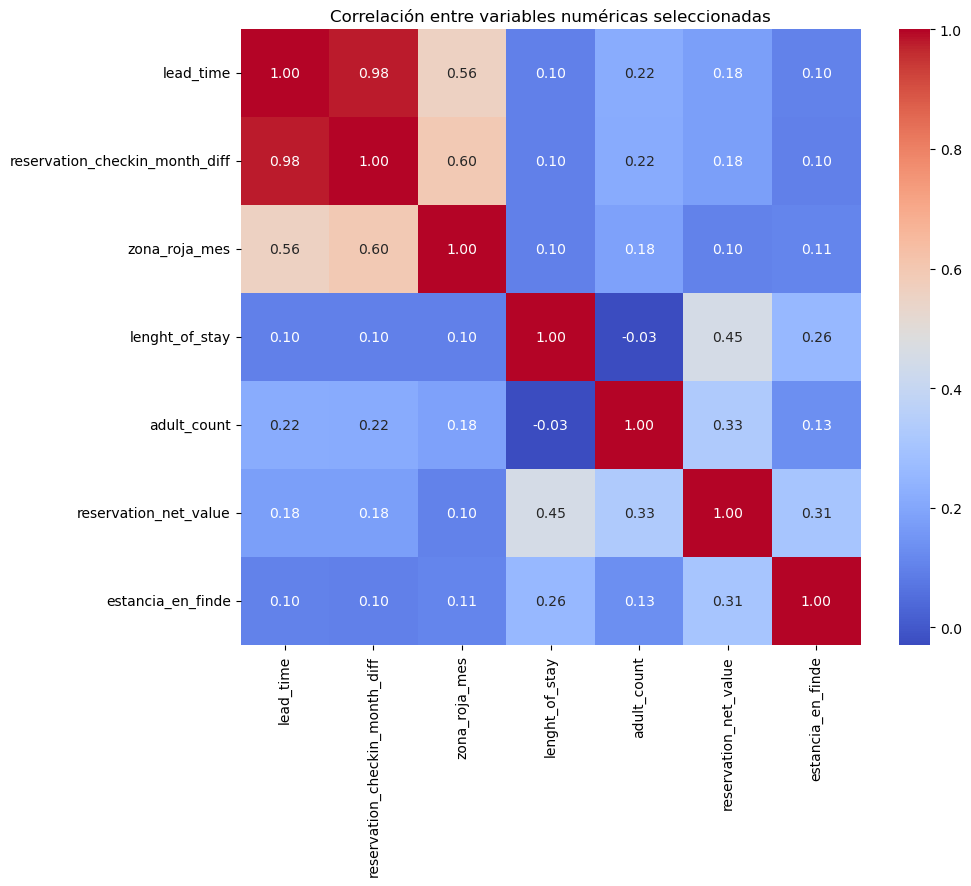

In [50]:
# Quedarnos solo con las mayores a 0.05:

# Decisión sobre el umbral: 
# Elegimos |corr| >= 0.05
# Justificación:
# - 0.05 es un umbral bajo, pero en problemas de comportamiento humano incluso señales débiles
#   pueden aportar información combinada
# - 0.10 sería más restrictivo y dejaría fuera variables con efecto pequeño pero útil

umbral = 0.05
vars_numericas_filtradas = corr_num[corr_num.abs() >= umbral].index.tolist()

print("Variables numéricas seleccionadas (|corr| >= 0.05):")
print(vars_numericas_filtradas)

# Revisar multicolinealidad entre las variables seleccionadas
# Para evitar pares altamente correlacionados (>0.7) que podrían afectar modelos lineales
# -----------------------------
corr_variables = df[vars_numericas_filtradas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_variables)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_variables, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre variables numéricas seleccionadas")
plt.show()

# -----------------------------
# Observaciones sobre la decisión:
# - Variables con mayor correlación con el target:
#   lead_time, reservation_checkin_month_diff, zona_roja_mes, lenght_of_stay
# - Variables con señal débil pero incluidas (|corr| ~ 0.05-0.08):
#   adult_count, reservation_net_value, estancia_en_finde
# - Ninguna variable presenta alta correlación entre sí (>0.7)
# - Decisión final: usar todas las variables seleccionadas con |corr| >= 0.05
#   para modelar cancelaciones, porque incluso señales débiles combinadas
#   pueden aportar información útil
# -----------------------------

#### BINARIAS

In [51]:
# 2.  BINARIAS

# 2.1 Detectar columnas binarias (0/1 o True/False)
binarias_vars = []

for columna in df_junto.columns:
    valores_unicos = df_junto[columna].dropna().unique()
    valores_set = set(valores_unicos)
    
    if valores_set.issubset({0, 1}) or valores_set.issubset({True, False}):
        # Excluir el target
        if columna != 'status_bool':
            binarias_vars.append(columna)

print("Variables binarias detectadas:")
print(binarias_vars)

Variables binarias detectadas:
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [52]:
# 2.2 Revisar impacto sobre el target
target_col = 'status_bool'

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    print(f'\nColumna: {columna}')
    print(medias)


Columna: zona_roja_mes
zona_roja_mes
0    0.191143
1    0.352428
Name: status_bool, dtype: float64

Columna: estancia_en_festivo
estancia_en_festivo
0    0.229083
1    0.254162
Name: status_bool, dtype: float64

Columna: estancia_en_finde
estancia_en_finde
0    0.198288
1    0.267638
Name: status_bool, dtype: float64


In [53]:
# 2.3 Filtrar variables binarias relevantes
bin_vars_relevantes = []

umbral_diferencia = 0.02  # 2%

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    diferencia = abs(medias.iloc[1] - medias.iloc[0])
    
    if diferencia > umbral_diferencia:
        bin_vars_relevantes.append(columna)

print("\nVariables binarias relevantes (diferencia > 0.02):")
print(bin_vars_relevantes)


# -----------------------------
# Justificación:
# Consideramos relevantes aquellas variables binarias donde la diferencia 
# en la media del target entre los dos grupos supera el 2%. Diferencias pequeñas
# pueden aportar información combinada con otras variables, pero se priorizan
# aquellas con un impacto más claro sobre la cancelación.
# -----------------------------



Variables binarias relevantes (diferencia > 0.02):
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


#### CATEGORICAS

In [54]:
# 3.  CATEGÓRICAS 

# 3.1 Detectar columnas categóricas
cat_vars = []

for columna in df_junto.columns:
    if df_junto[columna].dtype.name in ['object', 'category']:
        # Excluir la columna target
        if columna != 'status_bool':
            cat_vars.append(columna)

print("Variables categóricas detectadas:")
print(cat_vars)

Variables categóricas detectadas:
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'asset_type', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Estancia', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


In [55]:
# 3.2 Analizar impacto de variables categóricas sobre el target

target_col = 'status_bool'

for columna in cat_vars:
    # Calcular la media del target por cada categoría
    medias = df_junto.groupby(columna)[target_col].mean().sort_values(ascending=False)
    
    #print(f'\nVariable categórica: {columna}')
    #display(medias.head(10))  # Mostrar las 10 categorías con mayor media

In [56]:
# 3.3 Selección de variables categóricas relevantes

cat_vars_significativas = []

umbral_cat = 0.03  # 3%

for col in cat_vars:
    # Calcular la media del target por cada categoría
    medias_target = df_junto.groupby(col)[target_col].mean()
    
    # Diferencia máxima entre las categorías
    diferencia_max = medias_target.max() - medias_target.min()
    
    # Filtrar si supera el umbral
    if diferencia_max > umbral_cat:
        cat_vars_significativas.append(col)

print("\nVariables categóricas consideradas relevantes (diferencia > 0.03):")
print(cat_vars_significativas)

# Justificación:
# Se consideran relevantes aquellas variables categóricas donde la diferencia
# entre la categoría con mayor y menor media del target ('status_bool')
# supera el 3%. Esto refleja un impacto más claro sobre la probabilidad
# de cancelación, mientras que diferencias menores podrían aportar menos información.



Variables categóricas consideradas relevantes (diferencia > 0.03):
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


### Crear DataFrame Final para Modelado 

In [57]:
# CREAR DATAFRAME FINAL PARA MODELADO

# Unir todas las variables seleccionadas con el target
df_modelado_final = df_junto[
    vars_numericas_filtradas +       # Variables numéricas seleccionadas
    bin_vars_relevantes +            # Variables binarias relevantes
    cat_vars_significativas +        # Variables categóricas relevantes
    [target_col]                     # Target
]

# Verificar dimensiones
print(f"Dimensiones: {df_modelado_final.shape}")


Dimensiones: (51707, 35)


### Formatear el Data Frame (Numericas = Escalar, Categoricas = Dummies)

In [58]:
#Eliminar columnas de tipo fecha ya que no aportaran ningun tipo de informacion para el modelo
df_modelado_final = df_modelado_final.drop(columns=["fecha", "horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin"])

#### Escalar Variables Numericas

In [59]:
# Función para escalar variables numéricas con MinMaxScaler
def escalar_numericas(df, columnas_numericas=None):
    """
    Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_numericas : list (opcional)
        Lista de columnas numéricas. Si no se pasa, se detectan automáticamente.
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas numéricas escaladas entre 0 y 1.
    """

    df_copy = df.copy()

    # Detectar columnas numéricas si no se pasan
    if columnas_numericas is None:
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

    scaler = MinMaxScaler()

    # Escalar solo las numéricas
    df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas])

    return df_copy

# Aplicar la función al DataFrame
df_modelado_final = escalar_numericas(df_modelado_final)

# Revisar resultado
print("Primeras filas del DataFrame con variables numéricas escaladas:")
print(df_modelado_final.head())

Primeras filas del DataFrame con variables numéricas escaladas:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde  zona_roja_mes  \
0          0.1               0.015921                1.0            0.0   
1          0.1               0.117788                1.0            0.0   
2          0.2               0.755703                1.0            0.0   
3          0.2               0.186383                1.0            1.0   
4          0.4               0.077025                1.0            1.0   

   estanci

#### Convertir Categoricas a dummies

In [60]:
def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convertir a dummies
    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies

# Aplicar la función al DataFrame escalado
# =========================================================
df_modelado_final = convertir_a_dummies(df_modelado_final)

# Revisar resultado
print("DataFrame final con variables categóricas convertidas a dummies:")
print(df_modelado_final.head())
print(f"Dimensiones finales: {df_modelado_final.shape}")

DataFrame final con variables categóricas convertidas a dummies:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde  zona_roja_mes  \
0          0.1               0.015921                1.0            0.0   
1          0.1               0.117788                1.0            0.0   
2          0.2               0.755703                1.0            0.0   
3          0.2               0.186383                1.0            1.0   
4          0.4               0.077025                1.0            1.0   

   estanc

#### Eliminar filas duplicadas:

In [61]:
# Revisar duplicados considerando todas las columnas excepto el target
duplicados = df_modelado_final.drop(columns=['status_bool']).duplicated(keep=False)
print("Filas duplicadas:", duplicados.sum())


Filas duplicadas: 5011


In [62]:
# Eliminar duplicados exactos en las features
df_modelado_final = df_modelado_final.drop_duplicates()
print("Nuevo tamaño del DataFrame:", df_modelado_final.shape)


Nuevo tamaño del DataFrame: (48759, 118)


### ----------------------------------------------------------------------------------------------------------------------------------------

### PCA 

In [63]:
# 1. Preparar los datos para PCA
# Excluir el target 'status_bool' para PCA
X = df_modelado_final.drop(columns=['status_bool'])
y = df_modelado_final['status_bool']

# 2️. Aplicar PCA
# Crear el objeto PCA, podemos empezar con todas las componentes
pca = PCA()
X_pca = pca.fit_transform(X)

In [64]:
# 3. Explicación de la varianza
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Varianza acumulada
cumulative_variance = explained_variance.cumsum()

# Crear un DataFrame para visualizar
pca_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Varianza Explicada': explained_variance,
    'Varianza Acumulada': cumulative_variance
})

print("Varianza explicada por cada componente:")
print(pca_df.head(10))

Varianza explicada por cada componente:
  Componente  Varianza Explicada  Varianza Acumulada
0        PC1            0.138760            0.138760
1        PC2            0.093527            0.232286
2        PC3            0.080171            0.312458
3        PC4            0.057978            0.370436
4        PC5            0.054781            0.425217
5        PC6            0.046211            0.471428
6        PC7            0.042652            0.514080
7        PC8            0.038056            0.552136
8        PC9            0.028095            0.580231
9       PC10            0.025822            0.606053


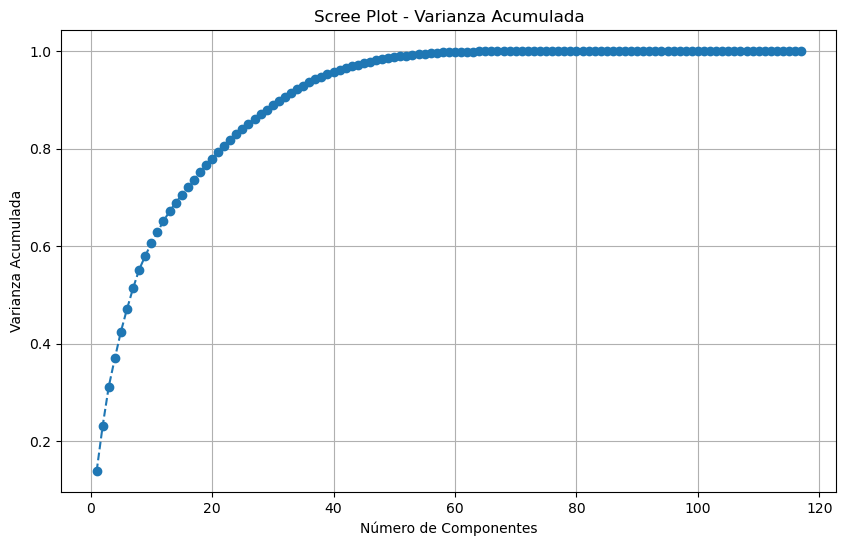

In [65]:
# 4️. Gráfico de scree plot (varianza acumulada)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot - Varianza Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()

In [66]:
# 5. Elegir el número de componentes
# Aplicar ~90% de la varianza
n_components_90 = (cumulative_variance < 0.90).sum() + 1
print(f"Número de componentes para explicar ~90% de la varianza: {n_components_90}")

Número de componentes para explicar ~90% de la varianza: 32


In [67]:
# 6. Crear DataFrame PCA final
# Podemos quedarnos solo con las primeras n componentes
pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X)

df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['status_bool'] = y.values  # añadir el target para el modelado

print("Primeras filas del DataFrame PCA:")
print(df_pca.head())

Primeras filas del DataFrame PCA:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.214097 -1.052055  1.370097  0.796588  0.349127 -0.753178 -0.390721   
1  0.244586 -1.069116  1.286692  0.834759  0.333689 -0.640275 -0.196561   
2 -0.036628 -0.926119  1.519082  0.844379  0.433176 -0.579410 -0.341844   
3 -0.083233 -0.992277  1.617261  1.210528  0.667758  0.051767  0.346978   
4 -0.089008 -1.021522  1.595324  1.169076  0.673627 -0.024111  0.338228   

        PC8       PC9      PC10  ...      PC24      PC25      PC26      PC27  \
0 -0.248487  0.345844  0.634853  ...  0.349502 -0.440109  0.307777  0.794073   
1 -0.240995  0.139565  1.354408  ...  0.553715 -0.487165  0.726280 -0.240361   
2 -0.241782 -0.245781  0.040918  ...  0.256574 -0.296392 -0.148987  0.074170   
3  0.081553 -0.337688  0.027421  ...  0.091835 -0.276321  0.085846  1.080151   
4  0.087820  0.138703  0.486876  ... -0.103815 -0.256765 -0.120684  0.214116   

       PC28      PC29      PC30   

### Train / Test

In [68]:
# 1. Separar el df y target
X = df_modelado_final.drop(columns=['status_bool', 'status_checked_out'])  # todas las variables excepto el target
y = df_modelado_final['status_bool']                 # target

# 2. División en train y test
# test_size = 0.2 → 20% de los datos para test
# stratify = y → asegura que la proporción de clases en train/test sea la misma que en el dataset original
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Comprobar tamaños
print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test:  {X_test.shape}")
print(f"Tamaño y_train: {y_train.shape}")
print(f"Tamaño y_test:  {y_test.shape}")

Tamaño X_train: (39007, 116)
Tamaño X_test:  (9752, 116)
Tamaño y_train: (39007,)
Tamaño y_test:  (9752,)


In [69]:
# 4️. Comprobar proporción de clases (opcional)
print("Proporción de clases en el train:")
print(y_train.value_counts(normalize=True).reset_index())
print("")
print("Proporción de clases en el test:")
print(y_test.value_counts(normalize=True).reset_index())

Proporción de clases en el train:
   status_bool  proportion
0          0.0    0.771118
1          1.0    0.228882

Proporción de clases en el test:
   status_bool  proportion
0          0.0    0.771124
1          1.0    0.228876


### Razon por la que se hace SMOTE: Datos desbalanceados

#### Prepara SMOTE

In [85]:
from imblearn.over_sampling import SMOTE

# Instanciar SMOTE
smote = SMOTE(random_state=42)

# Aplicar solo al conjunto de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Comparar districuion sin balancear y balanceando:

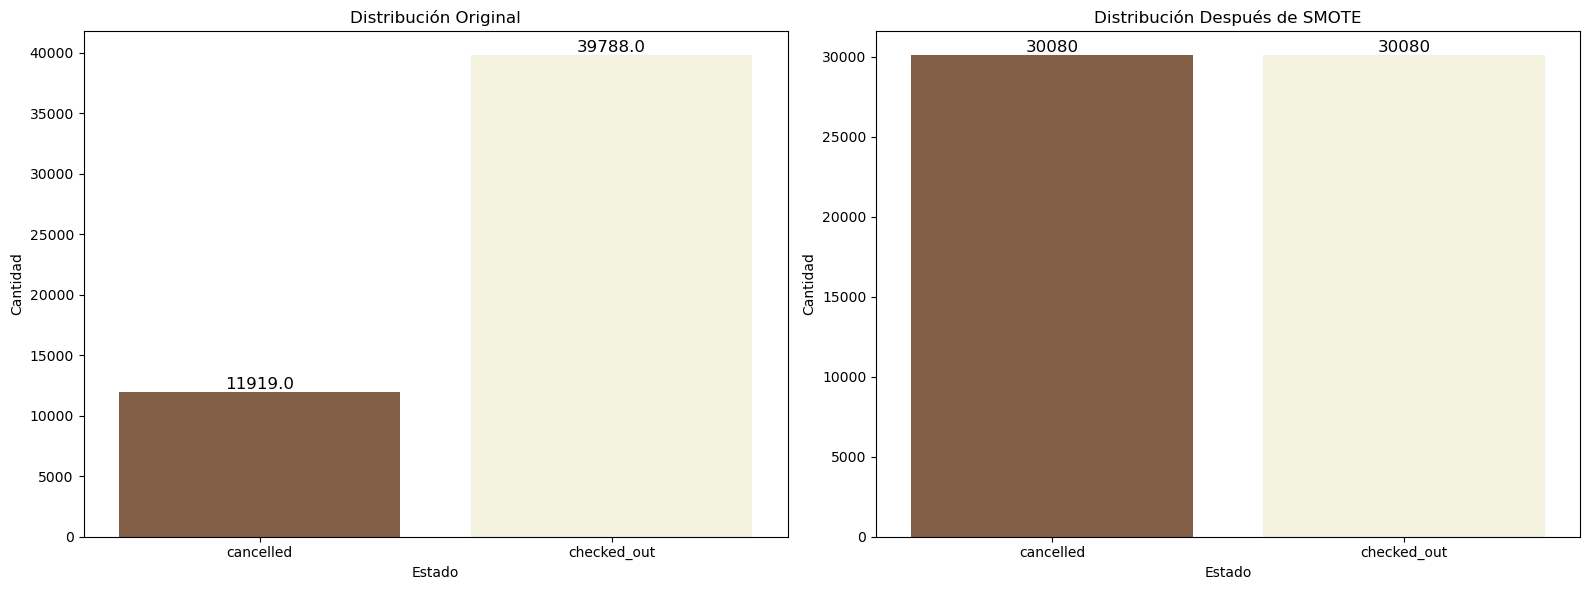

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Contar clases después de SMOTE
count_resampled = Counter(y_train_res)
df_resampled = pd.DataFrame({
    'status': ['cancelled', 'checked_out'],
    'Cantidad': [count_resampled[0], count_resampled[1]]
})

# Colores
colors = ["#8B5E3C", "#F5F5DC"]  

# Crear subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Gráfico original ---
ax0 = axes[0]
sns.countplot(data=df_junto, x="status", palette=colors, ax=ax0)
for p in ax0.patches:
    height = p.get_height()
    ax0.annotate(f'{height}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax0.set_title("Distribución Original")
ax0.set_xlabel("Estado")
ax0.set_ylabel("Cantidad")

# --- Gráfico después de SMOTE ---
ax1 = axes[1]
sns.barplot(data=df_resampled, x='status', y='Cantidad', palette=colors, ax=ax1)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax1.set_title("Distribución Después de SMOTE")
ax1.set_xlabel("Estado")
ax1.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

# Sin balancear
# reservas canceladas : 11919
# Reservas no canceladas: 39788

# Balanceando:
# Reservas canceladas: 30080
# Reserbas no canceladas:


# =========================================

# MODELOS CLASIFICACIÓN

# ========================================

# MODELOS REGRESION LOGISTICA

## 1.1º Modelo: Regresion Logistica (baseline)

In [71]:
# Regresión Logística

# 1.1 Instanciar el modelo
logreg = LogisticRegression(max_iter=1000) 
logreg

# 1.2 Entrenar el modelo
logreg_result = logreg.fit(X_train, y_train)

# 1.3 Predicciones
y_pred_classes = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:,1]  # probabilidad de clase positiva

# 1.4 Coeficientes y Odds Ratios
coefficients = logreg.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train.shape[1])
print("Coeficientes:", coefficients[0:5]) #Los primeros 5
print("Odds Ratios:", odds_ratios[0:5]) #Los primeros 5


Número de features: 116
Coeficientes: [4.13854586 1.97108204 0.24675528 7.4513486  0.86648634]
Odds Ratios: [6.27115639e+01 7.17843964e+00 1.27986586e+00 1.72218412e+03
 2.37853877e+00]


#### Evaluacion del Modelo

In [72]:
# 3.5 Evaluación del modelo
mean_accuracy = logreg.score(X_test, y_test)
auc = roc_auc_score(y_test, y_pred_classes)

print('Precisión media en test: {:.4f}'.format(mean_accuracy))
print('Área bajo la curva ROC (AUC): {:.4f}'.format(auc))

# 3.6 Reporte de clasiicación
print("Classification Report:\n")
print(classification_report(y_test, y_pred_classes, digits=4))


Precisión media en test: 0.7944
Área bajo la curva ROC (AUC): 0.5888
Classification Report:

              precision    recall  f1-score   support

         0.0     0.8049    0.9680    0.8789      7520
         1.0     0.6601    0.2097    0.3183      2232

    accuracy                         0.7944      9752
   macro avg     0.7325    0.5888    0.5986      9752
weighted avg     0.7718    0.7944    0.7506      9752



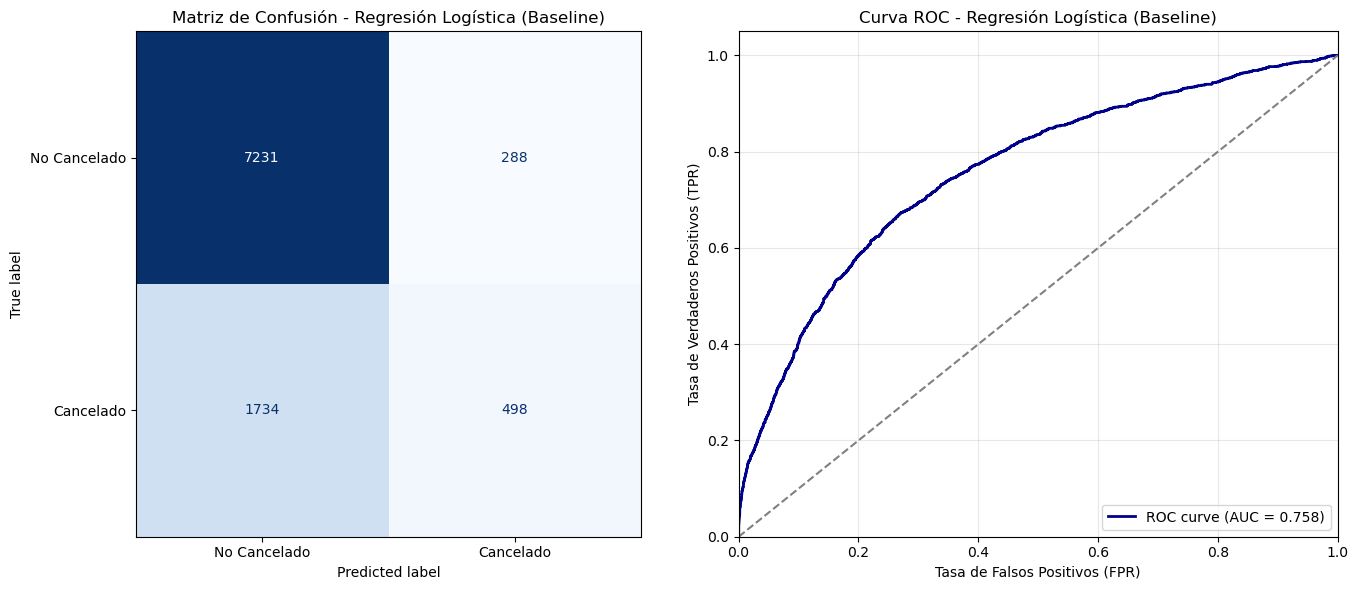

In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])

# --- Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión con valores dentro de las celdas
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Regresión Logística (Baseline)")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Regresión Logística (Baseline)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Visualizacion de probabilidades predichas

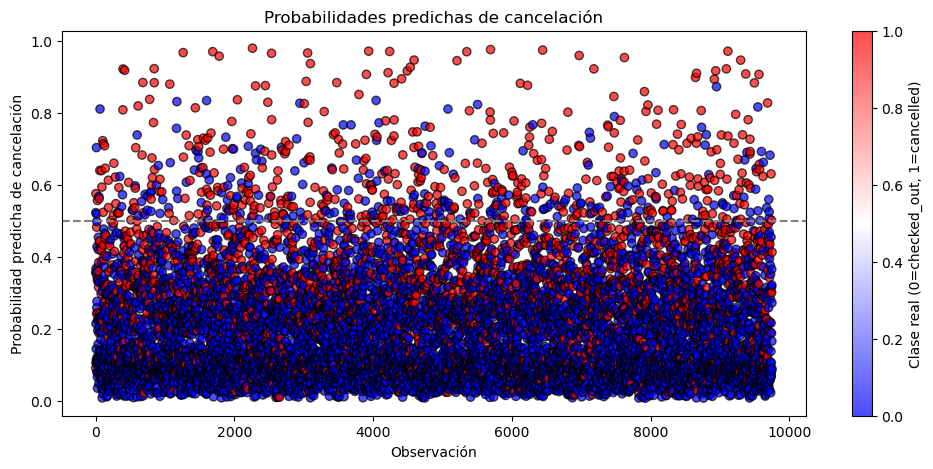

In [74]:
plt.figure(figsize=(12,5))
plt.scatter(range(len(y_test)), y_pred_proba, c=y_test, cmap='bwr', alpha=0.7, edgecolor='k')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Probabilidades predichas de cancelación")
plt.xlabel("Observación")
plt.ylabel("Probabilidad predicha de cancelación")
plt.colorbar(label='Clase real (0=checked_out, 1=cancelled)')
plt.show()

In [75]:
# 5. Interpretación de la variables: importancia de variables

# Crear un DataFrame con feature names y sus coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coefficients,
    'OddsRatio': odds_ratios
}).sort_values(by='OddsRatio', ascending=False)

print("Top 10 variables por efecto (Odds Ratio):")
print(coef_df.head(10))

Top 10 variables por efecto (Odds Ratio):
                                Variable  Coeficiente    OddsRatio
3                         lenght_of_stay     7.451349  1722.184117
0                              lead_time     4.138546    62.711564
1         reservation_checkin_month_diff     1.971082     7.178440
58    business_segment_Travel Individual     1.890476     6.622523
51  business_segment_Business Individual     1.786495     5.968495
53   business_segment_Leisure Individual     1.559866     4.758186
28                          origin_email     0.941767     2.564508
29                      origin_in_person     0.882214     2.416243
4                            adult_count     0.866486     2.378539
30                      origin_telephone     0.680237     1.974346


In [76]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Crear tabla
metricas_REGRESION_LOGISTICA = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression"])

metricas_REGRESION_LOGISTICA

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.794401,0.660085,0.209677,0.318259,0.769301


In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

# Separar X e y
X = df_modelado_final.drop(columns=['status_bool', "status_checked_out"])
y = df_modelado_final['status_bool']

# Logistic Regression con regularización L2
logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, solver='liblinear')

# Validación cruzada 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = []
f1_scores = []
conf_matrices = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    y_proba = logreg.predict_proba(X_test)[:,1]
    
    roc_auc_scores.append(roc_auc_score(y_test, y_proba))
    f1_scores.append(f1_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

print("ROC-AUC (5-fold):", np.mean(roc_auc_scores))
print("F1-score (5-fold):", np.mean(f1_scores))
print("Confusión promedio:\n", np.mean(conf_matrices, axis=0))


ROC-AUC (5-fold): 0.7636392147782038
F1-score (5-fold): 0.32078515162238785
Confusión promedio:
 [[7259.   260.8]
 [1755.8  476.2]]


### 1.2º Modelo: Regresion Logistica + GridSearch:

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# 1. Instanciar el modelo base
logreg = LogisticRegression(max_iter=1000, solver='liblinear') 


# 2️. Definir grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# 3️. Configurar GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 4️. Entrenar GridSearch con los datos de entrenamiento
grid_logreg.fit(X_train, y_train)

# Mejor modelo
logreg_best = grid_logreg.best_estimator_
print("Mejores parámetros:", grid_logreg.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'C': 100, 'penalty': 'l1'}


In [79]:
# 5️. Predicciones
y_pred_classes = logreg_best.predict(X_test)
y_pred_proba = logreg_best.predict_proba(X_test)[:,1]  # probabilidad de clase positiva

# 6️. Coeficientes y Odds Ratios
coefficients = logreg_best.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train.shape[1])
print("Coeficientes (primeros 5):", coefficients[0:5])
print("Odds Ratios (primeros 5):", odds_ratios[0:5])

Número de features: 116
Coeficientes (primeros 5): [ 8.69862671e+00 -2.10326648e+00  9.10791545e-03  1.10213973e+01
  1.03423776e+00]
Odds Ratios (primeros 5): [5.99467413e+03 1.22057079e-01 1.00914952e+00 6.11690938e+04
 2.81296127e+00]


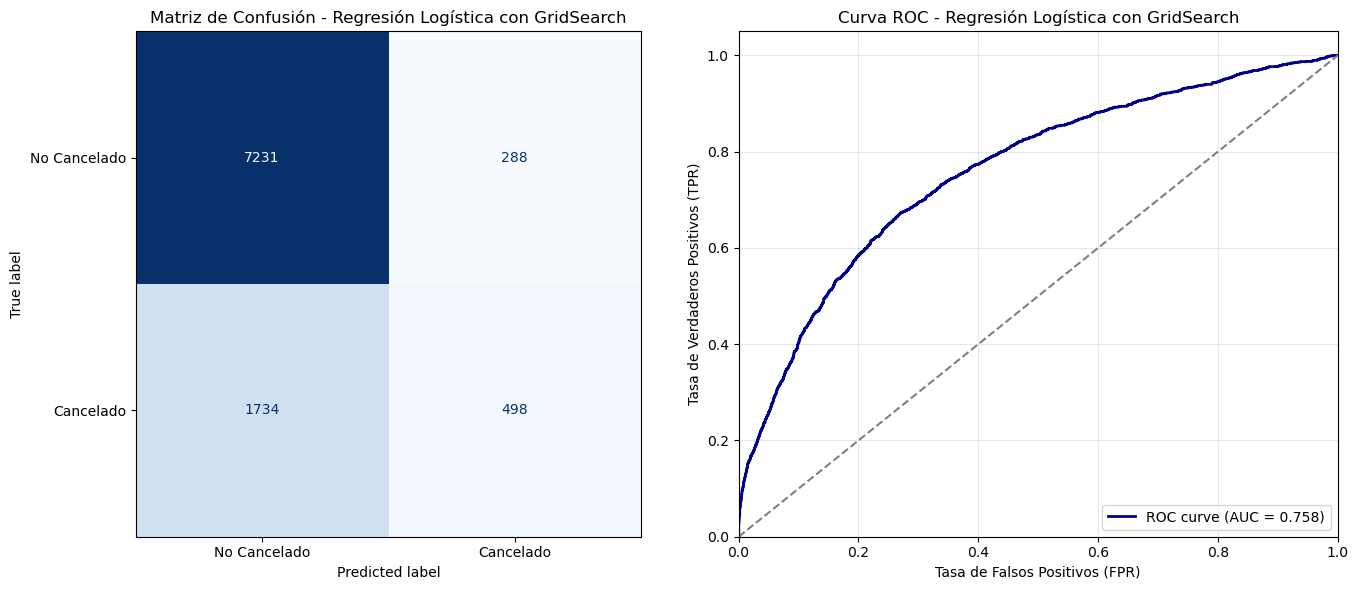

In [98]:
# 7️. Evaluación del modelo
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred_classes)  # No hace falta labels si las clases están en 0/1
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])

# --- Curva ROC ---
y_pred_proba = logreg_best.predict_proba(X_test)[:, 1]  # Probabilidad clase positiva
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión con valores dentro
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Regresión Logística con GridSearch")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Regresión Logística con GridSearch')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# Calcular métricas para el modelo con GridSearchCV
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Crear tabla de métricas
metricas_REGRESION_LOGISTICA_GRID = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression GridSearch"])

# Mostrar tabla
print(metricas_REGRESION_LOGISTICA_GRID)

In [81]:
# Comparacion con GridSearch y sin GridSearch:
print(metricas_REGRESION_LOGISTICA_GRID)
print(metricas_REGRESION_LOGISTICA)

                                Accuracy  Precision    Recall  F1-score  \
Logistic Regression GridSearch  0.792637   0.633588  0.223118   0.33002   

                                 ROC-AUC  
Logistic Regression GridSearch  0.758329  
                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.794401   0.660085  0.209677  0.318259  0.769301


Interpretación Resultados: Los resutlados no mejoran mucho tra aplicar Gridsearch es por ello que aplicaremos Smote y Smote + Gridsearch

### 1.3º Modelo: Regresion Logistica SMOTE

In [ ]:
# Entrenamiento modelo Regresion con SMOTE:
logreg_smote = LogisticRegression(max_iter=1000)
logreg_smote.fit(X_train_res, y_train_res)

y_pred_logreg_smote = logreg_smote.predict(X_test)
y_proba_logreg_smote = logreg_smote.predict_proba(X_test)[:,1]

In [ ]:
#Calcular metricas:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


accuracy = accuracy_score(y_test, y_pred_logreg_smote)
precision = precision_score(y_test, y_pred_logreg_smote)
recall = recall_score(y_test, y_pred_logreg_smote)
f1 = f1_score(y_test, y_pred_logreg_smote)
roc_auc = roc_auc_score(y_test, y_proba_logreg_smote)

# Crear tabla de métricas
metricas_LOGREG_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression SMOTE"])

# Mostrar tabla
metricas_LOGREG_SMOTE

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression SMOTE,0.709568,0.401639,0.548835,0.463839,0.712857


### 1.4º Modelo: Regresion Logistica SMOTE + GridSerch

In [ ]:
# Instanciar modelo base:
logreg = LogisticRegression(max_iter=1000, solver='liblinear')

#Definir grid de hiperparametros:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Configurar GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1)

# Entrenar GridSearch con SMOTE
grid_logreg.fit(X_train_res, y_train_res)

# Mejor modelo
logreg_best = grid_logreg.best_estimator_
print("Mejores parámetros (GridSearch + SMOTE):", grid_logreg.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros (GridSearch + SMOTE): {'C': 100, 'penalty': 'l1'}


In [ ]:
# Predicciones sobre el conjunto de test
y_pred_classes = logreg_best.predict(X_test)
y_pred_proba = logreg_best.predict_proba(X_test)[:,1]

# -----------------------------
# Coeficientes y Odds Ratios
coefficients = logreg_best.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train.shape[1])
print("Coeficientes (primeros 5):", coefficients[0:5])
print("Odds Ratios (primeros 5):", odds_ratios[0:5])

Número de features: 116
Coeficientes (primeros 5): [ 9.79369477e+00 -1.68908912e+00  3.39575353e-03  7.16918147e+00
  1.23474639e+00]
Odds Ratios (primeros 5): [1.79203957e+04 1.84687675e-01 1.00340153e+00 1.29878108e+03
 3.43750662e+00]


In [100]:
# Evaluación del modelo
mean_accuracy = logreg_best.score(X_test, y_test)
auc = roc_auc_score(y_test, y_pred_proba)

print('Precisión media en test: {:.4f}'.format(mean_accuracy))
print('Área bajo la curva ROC (AUC): {:.4f}'.format(auc))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, digits=4))

Precisión media en test: 0.7926
Área bajo la curva ROC (AUC): 0.7583

Classification Report:

              precision    recall  f1-score   support

         0.0     0.8066    0.9617    0.8773      7519
         1.0     0.6336    0.2231    0.3300      2232

    accuracy                         0.7926      9751
   macro avg     0.7201    0.5924    0.6037      9751
weighted avg     0.7670    0.7926    0.7521      9751



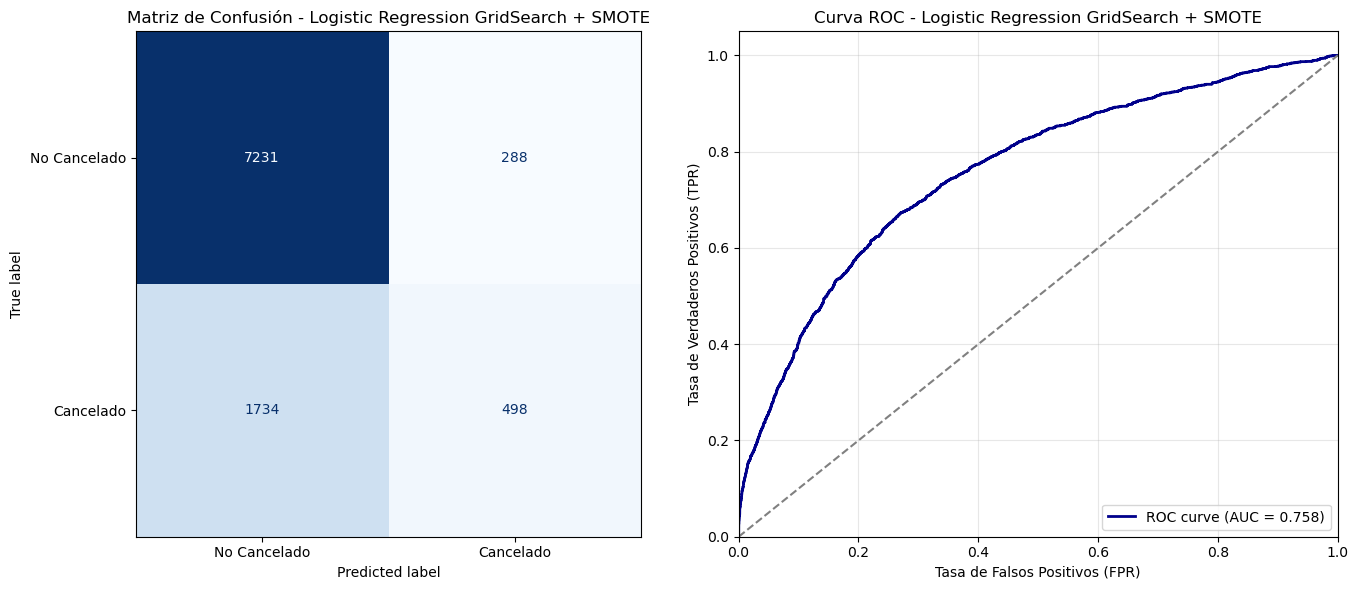

In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred_classes)  # No es necesario labels si las clases son 0/1
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])

# --- Curva ROC ---
y_pred_proba = logreg_best.predict_proba(X_test)[:, 1]  # Probabilidad clase positiva
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión con valores dentro de las celdas
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Logistic Regression GridSearch + SMOTE")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Logistic Regression GridSearch + SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Crear tabla de métricas
metricas_LOGREG_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_classes)],
    "Precision": [precision_score(y_test, y_pred_classes)],
    "Recall": [recall_score(y_test, y_pred_classes)],
    "F1-score": [f1_score(y_test, y_pred_classes)],
    "ROC-AUC": [roc_auc_score(y_test, y_pred_proba)]
}, index=["Logistic Regression GridSearch + SMOTE"])

metricas_LOGREG_GRID_SMOTE

### Comparar los tres diferentes modelos de REGRESION LOGISTICA:

In [ ]:
metricas_modelos_regresion_logistica = pd.concat([
    metricas_REGRESION_LOGISTICA,      
    metricas_REGRESION_LOGISTICA_GRID, 
    metricas_LOGREG_SMOTE,             
    metricas_LOGREG_GRID_SMOTE         ])

# Mostrar la tabla final
print(metricas_modelos_regresion_logistica)

                                        Accuracy  Precision    Recall  \
Logistic Regression                     0.794401   0.660085  0.209677   
Logistic Regression GridSearch          0.792637   0.633588  0.223118   
Logistic Regression SMOTE               0.709568   0.401639  0.548835   
Logistic Regression GridSearch + SMOTE  0.712850   0.405960  0.549283   

                                        F1-score   ROC-AUC  
Logistic Regression                     0.318259  0.769301  
Logistic Regression GridSearch          0.330020  0.758329  
Logistic Regression SMOTE               0.463839  0.712857  
Logistic Regression GridSearch + SMOTE  0.466870  0.713755  


Seleccion Modelo: Elegimos **Logistic Regression + SMOTE** (con GridSearch) porque maximiza Recall (~0.55) y F1-score (~0.467), detectando mejor las cancelaciones. 
Aunque Precision y Accuracy bajan, esto es aceptable al priorizar la clase minoritaria.


In [ ]:
metricas_modelo_final_regresion_logistica = metricas_LOGREG_GRID_SMOTE

# ==============================================

# MODELOS NAIVE BAYES

## 2º Modelo: Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt

#Entrenamiento y prediccion:
# Instanciar modelo
gnb = GaussianNB()

# Entrenar y predecir
y_pred_nb = gnb.fit(X_train, y_train).predict(X_test)
y_proba_nb = gnb.predict_proba(X_test)[:, 1]  # probabilidad clase positiva


In [ ]:
# Priors de clase
print("Class Priors:")
print(gnb.class_prior_)

# Media de cada feature por clase
print("Means (theta):")
print(gnb.theta_)

# Desviación estándar de cada feature por clase
print("Standard Deviations:")
print(np.sqrt(gnb.var_))


Class Priors:
[0.77112387 0.22887613]
Means (theta):
[[3.23309291e-02 5.78390957e-02 2.02526596e-01 2.58054471e-02
  2.07293883e-01 1.96259962e-01 4.39926862e-01 2.02526596e-01
  5.60837766e-02 4.39926862e-01 1.05086436e-01 7.23736702e-02
  6.67553191e-02 6.63231383e-02 9.54122340e-02 9.01263298e-02
  6.84507979e-02 9.30186170e-02 6.76529255e-02 7.97872340e-02
  9.64760638e-02 1.46110372e-01 1.48470745e-01 1.26928191e-01
  1.39361702e-01 1.25099734e-01 1.41954787e-01 2.15093085e-01
  4.57114362e-02 1.09707447e-03 4.85704787e-02 2.68517287e-01
  2.22506649e-01 3.77327128e-02 2.24335106e-01 5.08976064e-02
  2.09441489e-03 5.18617021e-03 7.14760638e-02 9.17553191e-03
  3.25465426e-02 2.94215426e-02 2.01130319e-01 2.87566489e-02
  9.10904255e-02 4.69747340e-02 2.19747340e-02 7.23736702e-02
  3.03856383e-02 2.96210106e-02 2.40259309e-01 1.32313830e-02
  1.08045213e-02 9.28191489e-01 6.94813830e-03 3.15824468e-03
  8.64361702e-04 9.37500000e-03 2.51994681e-02 8.31117021e-04
  4.54521277e-01 

In [ ]:
# INTERPRETACIÓN GAUSSIAN NAIVE BAYES
#
# Class Priors:
# El modelo estima que el 77.1% de las observaciones pertenecen a la clase 0 y el 22.9%
# a la clase 1, lo que indica un desbalance de clases y posible sesgo hacia la clase mayoritaria.
#
# Means (theta):
# Representan la media de cada feature por clase. Diferencias entre clases indican
# variables con capacidad discriminativa dentro del modelo.
#
# Standard Deviations:
# Miden la variabilidad de cada feature en cada clase. Valores altos implican mayor
# solapamiento entre clases y pueden limitar el rendimiento del modelo.
#
# Interpretación global:
# El modelo combina priors y distribuciones normales bajo el supuesto de independencia
# entre variables, siendo un buen baseline pero menos flexible que modelos discriminativos.


In [ ]:
#Errores de clasificacion:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test != y_pred_nb).sum(), y_test.shape[0])
)


Número de puntos mal clasificados: 2856 de 9751


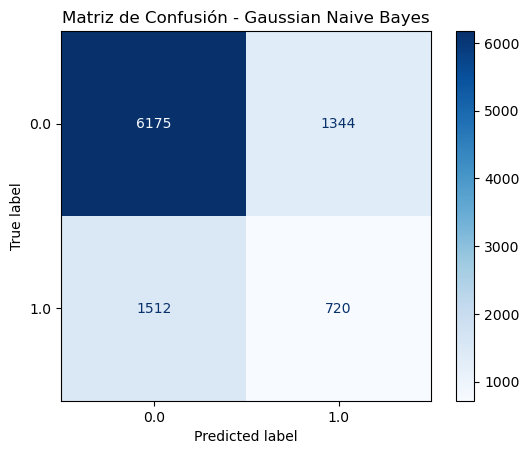

In [ ]:
# Matriz de confusion:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=gnb.classes_)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=gnb.classes_
)

disp_nb.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Gaussian Naive Bayes")
plt.show()


In [ ]:
# Clasification Report:
print("Classification Report - Gaussian Naive Bayes\n")
print(classification_report(y_test, y_pred_nb, digits=4))


Classification Report - Gaussian Naive Bayes

              precision    recall  f1-score   support

         0.0     0.8033    0.8213    0.8122      7519
         1.0     0.3488    0.3226    0.3352      2232

    accuracy                         0.7071      9751
   macro avg     0.5761    0.5719    0.5737      9751
weighted avg     0.6993    0.7071    0.7030      9751



In [ ]:
# Metricas tabla:
metricas_NAIVE_BAYES = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_nb)],
    "Precision": [precision_score(y_test, y_pred_nb)],
    "Recall": [recall_score(y_test, y_pred_nb)],
    "F1-score": [f1_score(y_test, y_pred_nb)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_nb)]
}, index=["Gaussian Naive Bayes"])

metricas_NAIVE_BAYES


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Gaussian Naive Bayes,0.707107,0.348837,0.322581,0.335196,0.656928


### 2.2º Modelo NAIVE BAYES Gridsearch

In [ ]:
# Parametros con gridsearch:
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

# Configurar GridSearch
grid_gnb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Entrenamiento con GridSearch
grid_gnb.fit(X_train, y_train)

# Mejor modelo de GridSearch
gnb_best = grid_gnb.best_estimator_
print(f"Mejor parámetro var_smoothing: {grid_gnb.best_params_['var_smoothing']}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor parámetro var_smoothing: 1e-09


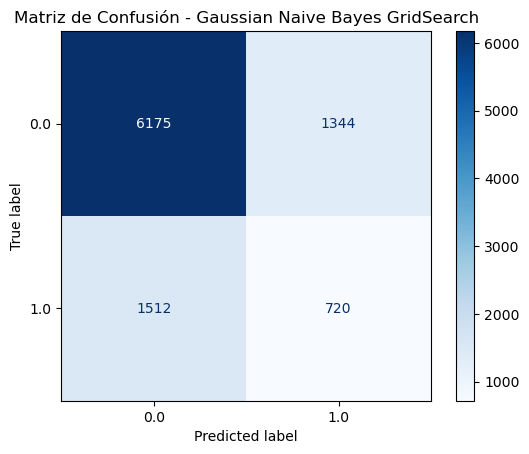

In [ ]:
# Predicción sobre test
y_pred_nb_grid = gnb_best.predict(X_test)
y_proba_nb_grid = gnb_best.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_nb_grid = confusion_matrix(y_test, y_pred_nb_grid)
disp_nb_grid = ConfusionMatrixDisplay(cm_nb_grid, display_labels=gnb_best.classes_)
disp_nb_grid.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Gaussian Naive Bayes GridSearch")
plt.show()

In [ ]:
# Clasification Report
print(classification_report(y_test, y_pred_nb_grid, digits=4))

# Calcular métricas
metricas_NAIVE_BAYES_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_nb_grid)],
    "Precision": [precision_score(y_test, y_pred_nb_grid)],
    "Recall": [recall_score(y_test, y_pred_nb_grid)],
    "F1-score": [f1_score(y_test, y_pred_nb_grid)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_nb_grid)]
}, index=["Gaussian Naive Bayes GridSearch"])

print(metricas_NAIVE_BAYES_GRID)

              precision    recall  f1-score   support

         0.0     0.8033    0.8213    0.8122      7519
         1.0     0.3488    0.3226    0.3352      2232

    accuracy                         0.7071      9751
   macro avg     0.5761    0.5719    0.5737      9751
weighted avg     0.6993    0.7071    0.7030      9751

                                 Accuracy  Precision    Recall  F1-score  \
Gaussian Naive Bayes GridSearch  0.707107   0.348837  0.322581  0.335196   

                                  ROC-AUC  
Gaussian Naive Bayes GridSearch  0.656928  


### 2.3º Modelo NAIVE BAYES SMOTE

In [50]:
# Instanciar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE solo al entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Tamaño X_train después de SMOTE: {X_train_res.shape}, y_train: {y_train_res.shape}")

# Entrenar modelo con SMOTE
gnb_smote = GaussianNB()
gnb_smote.fit(X_train_res, y_train_res)

NameError: name 'SMOTE' is not defined

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Contar clases después de SMOTE
count_resampled = Counter(y_train_res)

# Crear DataFrame para graficar
import pandas as pd
df_resampled = pd.DataFrame({
    'status': ['No Cancelado', 'Cancelado'],
    'Cantidad': [count_resampled[0], count_resampled[1]]
})

# Definir colores: marrón oscuro y beige
colors = ["#8B5E3C", "#F5F5DC"]  

# Crear gráfico
plt.figure(figsize=(8,6))
ax = sns.barplot(data=df_resampled, x='status', y='Cantidad', palette=colors)

# Agregar etiquetas encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12)

# Títulos y etiquetas
plt.title("Distribución de clases después de SMOTE")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.show()


NameError: name 'y_train_res' is not defined

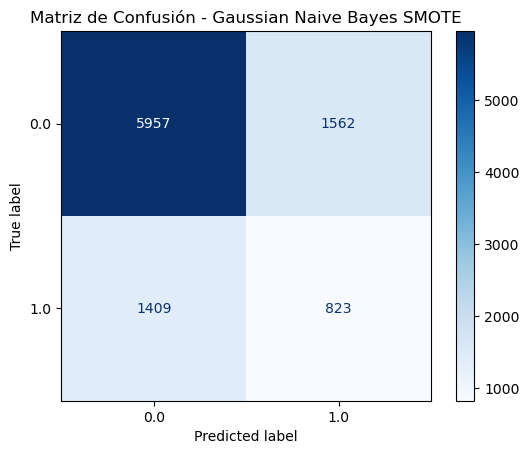

In [64]:
# Predicción sobre test
y_pred_nb_smote = gnb_smote.predict(X_test)
y_proba_nb_smote = gnb_smote.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_nb_smote = confusion_matrix(y_test, y_pred_nb_smote)
disp_nb_smote = ConfusionMatrixDisplay(cm_nb_smote, display_labels=gnb_smote.classes_)
disp_nb_smote.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Gaussian Naive Bayes SMOTE")
plt.show()

In [65]:
# Clasification Report
print(classification_report(y_test, y_pred_nb_smote, digits=4))

# Calcular métricas
metricas_NAIVE_BAYES_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_nb_smote)],
    "Precision": [precision_score(y_test, y_pred_nb_smote)],
    "Recall": [recall_score(y_test, y_pred_nb_smote)],
    "F1-score": [f1_score(y_test, y_pred_nb_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_nb_smote)]
}, index=["Gaussian Naive Bayes SMOTE"])

print(metricas_NAIVE_BAYES_SMOTE)

              precision    recall  f1-score   support

         0.0     0.8087    0.7923    0.8004      7519
         1.0     0.3451    0.3687    0.3565      2232

    accuracy                         0.6953      9751
   macro avg     0.5769    0.5805    0.5785      9751
weighted avg     0.7026    0.6953    0.6988      9751

                            Accuracy  Precision    Recall  F1-score  ROC-AUC
Gaussian Naive Bayes SMOTE  0.695313   0.345073  0.368728  0.356509  0.64436


### 2.4º Modelo: NAIVE BAYES SMOTE + Gridsearch

In [66]:
# GridSearch sobre datos con SMOTE
grid_gnb_smote = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento con SMOTE + GridSearch
grid_gnb_smote.fit(X_train_res, y_train_res)

# Mejor modelo
gnb_best_smote = grid_gnb_smote.best_estimator_
print(f"Mejor parámetro var_smoothing (GridSearch + SMOTE): {grid_gnb_smote.best_params_['var_smoothing']}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor parámetro var_smoothing (GridSearch + SMOTE): 1e-05


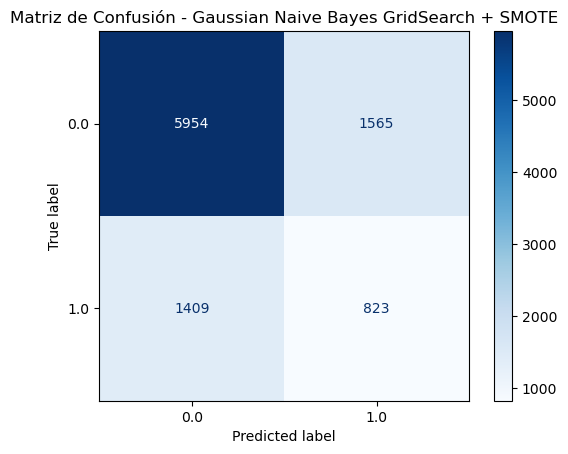

In [67]:
# Predicción sobre test
y_pred_nb_grid_smote = gnb_best_smote.predict(X_test)
y_proba_nb_grid_smote = gnb_best_smote.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_nb_grid_smote = confusion_matrix(y_test, y_pred_nb_grid_smote)
disp_nb_grid_smote = ConfusionMatrixDisplay(cm_nb_grid_smote, display_labels=gnb_best_smote.classes_)
disp_nb_grid_smote.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Gaussian Naive Bayes GridSearch + SMOTE")
plt.show()

In [68]:
# Clasification Report
print(classification_report(y_test, y_pred_nb_grid_smote, digits=4))

# Calcular métricas
metricas_NAIVE_BAYES_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_nb_grid_smote)],
    "Precision": [precision_score(y_test, y_pred_nb_grid_smote)],
    "Recall": [recall_score(y_test, y_pred_nb_grid_smote)],
    "F1-score": [f1_score(y_test, y_pred_nb_grid_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_nb_grid_smote)]
}, index=["Gaussian Naive Bayes GridSearch + SMOTE"])

print(metricas_NAIVE_BAYES_GRID_SMOTE)


              precision    recall  f1-score   support

         0.0     0.8086    0.7919    0.8002      7519
         1.0     0.3446    0.3687    0.3563      2232

    accuracy                         0.6950      9751
   macro avg     0.5766    0.5803    0.5782      9751
weighted avg     0.7024    0.6950    0.6986      9751

                                         Accuracy  Precision    Recall  \
Gaussian Naive Bayes GridSearch + SMOTE  0.695006    0.34464  0.368728   

                                         F1-score  ROC-AUC  
Gaussian Naive Bayes GridSearch + SMOTE  0.356277  0.64434  


### Comparacion final de todos los modeloe NAIVE BAYES

In [69]:
# Comparación final de todos los modelos Naive Bayes
metricas_modelos_naive_bayes = pd.concat([
    metricas_NAIVE_BAYES, 
    metricas_NAIVE_BAYES_GRID, 
    metricas_NAIVE_BAYES_SMOTE, 
    metricas_NAIVE_BAYES_GRID_SMOTE])

print(metricas_modelos_naive_bayes)

                                         Accuracy  Precision    Recall  \
Gaussian Naive Bayes                     0.707107   0.348837  0.322581   
Gaussian Naive Bayes GridSearch          0.707107   0.348837  0.322581   
Gaussian Naive Bayes SMOTE               0.695313   0.345073  0.368728   
Gaussian Naive Bayes GridSearch + SMOTE  0.695006   0.344640  0.368728   

                                         F1-score   ROC-AUC  
Gaussian Naive Bayes                     0.335196  0.656928  
Gaussian Naive Bayes GridSearch          0.335196  0.656928  
Gaussian Naive Bayes SMOTE               0.356509  0.644360  
Gaussian Naive Bayes GridSearch + SMOTE  0.356277  0.644340  


Interpreaction Resultado:
1. Baseline vs GridSearch: No hay mejora significativa, los parámetros de GridSearch no aportan ventaja.
2. SMOTE (balanceo) mejora Recall (~0.368 vs 0.323) y F1-score (~0.357 vs 0.335), detectando más cancelaciones.
3. GridSearch + SMOTE no mejora respecto a SMOTE solo.
4. Accuracy y ROC-AUC bajan ligeramente con SMOTE, pero esto es aceptable si priorizamos detectar cancelaciones (minoritaria).

Conclusión: 
Mejor modelo para Naive Bayes: Gaussian Naive Bayes + SMOTE
Justificación: Maximiza Recall y F1-score, es más sensible a la clase minoritaria (cancelaciones).


In [70]:
metricas_modelo_final_naive_bayes = metricas_NAIVE_BAYES_GRID_SMOTE

# ===================================================

# MODELOS SUPPORT VECTOR MACHINE (SVM)

## 3.1º Modelo: Support Vector Machine (SVM)

In [141]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# Entrenamiento del modelo:
# Instanciar el modelo SVM
svm_clf = SVC(
    kernel='rbf',        # kernel no lineal
    C=1.0,               # regularización
    gamma='scale',       # influencia de cada punto
    probability=True,    # necesario para ROC-AUC
    random_state=42
)

# Entrenar modelo
svm_clf.fit(X_train, y_train)

In [ ]:
#Predicciones:
y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

In [ ]:
# Errores de clasificacion:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test != y_pred_svm).sum(), y_test.shape[0])
)

In [ ]:
# Matriz de confusion:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_clf.classes_)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_clf.classes_
)

disp_svm.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - SVM")
plt.show()


In [ ]:
#Clasification Report:
print("Classification Report - SVM\n")
print(classification_report(y_test, y_pred_svm, digits=4))

In [ ]:
#Tabla de metricas:
metricas_SVM = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_svm)],
    "Precision": [precision_score(y_test, y_pred_svm)],
    "Recall": [recall_score(y_test, y_pred_svm)],
    "F1-score": [f1_score(y_test, y_pred_svm)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_svm)]
}, index=["Support Vector Machine"])

metricas_SVM


### 3.2º Modelo: SVM Gridsearch

In [ ]:
# Definir grid de hiperparámetros
param_grid_svm = {
    'C': [0.1, 1, 10], #Pongo estos valores solo porque sino el tiempo de ejecucion sera muy muy largo
    'gamma': ['scale', 0.01]
}

# Configurar GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Entrenar GridSearch
grid_svm.fit(X_train, y_train)

# Mejor modelo
svm_best = grid_svm.best_estimator_
print(f"Mejores parámetros SVM: {grid_svm.best_params_}")

In [ ]:
# Predicción sobre test
y_pred_svm_grid = svm_best.predict(X_test)
y_proba_svm_grid = svm_best.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_svm_grid = confusion_matrix(y_test, y_pred_svm_grid)
disp_svm_grid = ConfusionMatrixDisplay(cm_svm_grid, display_labels=svm_best.classes_)
disp_svm_grid.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - SVM GridSearch")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_svm_grid, digits=4))

In [ ]:
# Calcular métricas
metricas_SVM_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_svm_grid)],
    "Precision": [precision_score(y_test, y_pred_svm_grid)],
    "Recall": [recall_score(y_test, y_pred_svm_grid)],
    "F1-score": [f1_score(y_test, y_pred_svm_grid)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_svm_grid)]
}, index=["SVM GridSearch"])

print(metricas_SVM_GRID)

### 3.3º Modelo: SVM SMOTE

In [ ]:
# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Tamaño X_train después de SMOTE: {X_train_res.shape}, y_train: {y_train_res.shape}")

# Entrenar SVM sobre datos balanceados
svm_smote = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_smote.fit(X_train_res, y_train_res)

In [ ]:
# Predicción sobre test
y_pred_svm_smote = svm_smote.predict(X_test)
y_proba_svm_smote = svm_smote.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_svm_smote = confusion_matrix(y_test, y_pred_svm_smote)
disp_svm_smote = ConfusionMatrixDisplay(cm_svm_smote, display_labels=svm_smote.classes_)
disp_svm_smote.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - SVM SMOTE")
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred_svm_smote, digits=4))

# Calcular métricas
metricas_SVM_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_svm_smote)],
    "Precision": [precision_score(y_test, y_pred_svm_smote)],
    "Recall": [recall_score(y_test, y_pred_svm_smote)],
    "F1-score": [f1_score(y_test, y_pred_svm_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_svm_smote)]
}, index=["SVM SMOTE"])

print("Métricas SMOTE:\n", metricas_SVM_SMOTE)

### 3.4º Modelo: SVM SMOTE + Gridsearch

In [ ]:
# GridSearch sobre datos balanceados
grid_svm_smote = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_svm_smote.fit(X_train_res, y_train_res)

# Mejor modelo
svm_best_smote = grid_svm_smote.best_estimator_
print(f"Mejores parámetros SVM (GridSearch + SMOTE): {grid_svm_smote.best_params_}")

In [ ]:
# Predicción sobre test
y_pred_svm_grid_smote = svm_best_smote.predict(X_test)
y_proba_svm_grid_smote = svm_best_smote.predict_proba(X_test)[:,1]

# Matriz de confusión
cm_svm_grid_smote = confusion_matrix(y_test, y_pred_svm_grid_smote)
disp_svm_grid_smote = ConfusionMatrixDisplay(cm_svm_grid_smote, display_labels=svm_best_smote.classes_)
disp_svm_grid_smote.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - SVM GridSearch + SMOTE")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_svm_grid_smote, digits=4))

In [ ]:
# Calcular métricas
metricas_SVM_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_svm_grid_smote)],
    "Precision": [precision_score(y_test, y_pred_svm_grid_smote)],
    "Recall": [recall_score(y_test, y_pred_svm_grid_smote)],
    "F1-score": [f1_score(y_test, y_pred_svm_grid_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_svm_grid_smote)]
}, index=["SVM GridSearch + SMOTE"])

print("Métricas GridSearch + SMOTE:\n", metricas_SVM_GRID_SMOTE)

### Comparacion metricas modelos SVM

In [ ]:
# Comparación de todos los modelos SVM
metricas_modelos_svm = pd.concat([
    metricas_SVM,
    metricas_SVM_GRID,
    metricas_SVM_SMOTE,
    metricas_SVM_GRID_SMOTE
])

print(metricas_modelos_svm)

### 4º Modelo: Arbol de Decision

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score


Codigo para la seleccion de los mejores parametros para el Modelo

In [ ]:

# 2. Modelo base
tree_clf = DecisionTreeClassifier(random_state=42)

# 3. Grid de hiperparámetros 
# Se reduce para que sea rápido pero efectivo
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7],      # probamos árboles de varias profundidades
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


# 4. Configurar GridSearchCV
# Optimiza F1-score usando validación cruzada
scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 5. Entrenar GridSearchCV
# Encuentra los mejores parámetros según F1-score promedio en CV
grid_search.fit(X, y)

# 6. Mostrar resultados 
print("Mejores parámetros:", grid_search.best_params_)

# Aplicaremos estos parametro al modelo apra entrenarlo:


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
# Entrenamiento modelo:
# Instanciar Árbol de Decisión
tree_clf = DecisionTreeClassifier(
    criterion='entropy',        # índice de Gini (también se puede usar 'entropy')
    max_depth=None,           # sin límite de profundidad, se puede ajustar
    random_state=42,
    min_samples_leaf=4,
    min_samples_split= 10
)

# Entrenar modelo
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=4,
                       min_samples_split=10, random_state=42)

In [ ]:
# Predicciones:
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

In [ ]:
# Numero de errores:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test != y_pred_tree).sum(), y_test.shape[0])
)

Número de puntos mal clasificados: 2194 de 9751


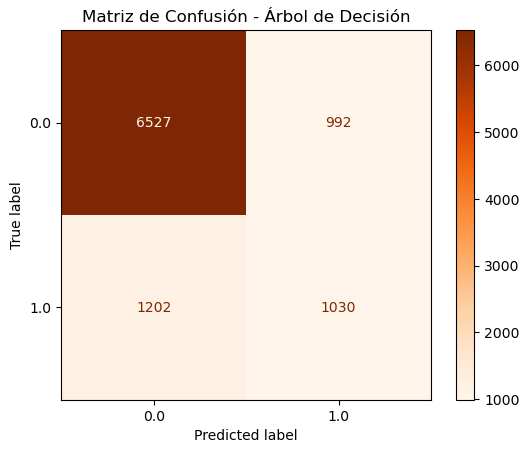

In [ ]:
# Matriz de confusion:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=tree_clf.classes_)

disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=tree_clf.classes_
)

disp_tree.plot(cmap=plt.cm.Oranges)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

In [ ]:
# Clasification report:
print("Classification Report - Árbol de Decisión\n")
print(classification_report(y_test, y_pred_tree, digits=4))

Classification Report - Árbol de Decisión

              precision    recall  f1-score   support

         0.0     0.8445    0.8681    0.8561      7519
         1.0     0.5094    0.4615    0.4843      2232

    accuracy                         0.7750      9751
   macro avg     0.6769    0.6648    0.6702      9751
weighted avg     0.7678    0.7750    0.7710      9751



In [ ]:
# Tabla metricas:
metricas_ARBOL_DECISION_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_tree)],
    "Precision": [precision_score(y_test, y_pred_tree)],
    "Recall": [recall_score(y_test, y_pred_tree)],
    "F1-score": [f1_score(y_test, y_pred_tree)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_tree)]
}, index=["Decision Tree"])
metricas_ARBOL_DECISION_GRID


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Decision Tree,0.774997,0.509397,0.46147,0.48425,0.722362


### 4.2º Modelo ARBOL DECISION SMOTE

In [ ]:
# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Entrenar modelo
tree_smote = DecisionTreeClassifier(random_state=42)
tree_smote.fit(X_train_res, y_train_res)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Predicciones
y_pred_tree_smote = tree_smote.predict(X_test)
y_proba_tree_smote = tree_smote.predict_proba(X_test)[:, 1]

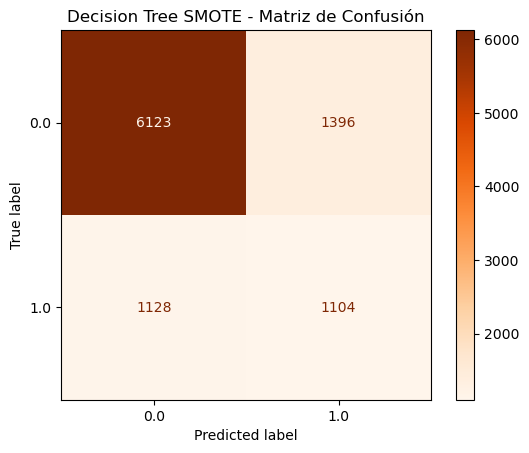

Decision Tree SMOTE - Classification Report:

              precision    recall  f1-score   support

         0.0     0.8444    0.8143    0.8291      7519
         1.0     0.4416    0.4946    0.4666      2232

    accuracy                         0.7412      9751
   macro avg     0.6430    0.6545    0.6479      9751
weighted avg     0.7522    0.7412    0.7461      9751



In [ ]:
# Matriz de confusión
cm_tree_smote = confusion_matrix(y_test, y_pred_tree_smote)
disp_tree_smote = ConfusionMatrixDisplay(cm_tree_smote, display_labels=tree_smote.classes_)
disp_tree_smote.plot(cmap=plt.cm.Oranges)
plt.title("Decision Tree SMOTE - Matriz de Confusión")
plt.show()

# Classification Report
print("Decision Tree SMOTE - Classification Report:\n")
print(classification_report(y_test, y_pred_tree_smote, digits=4))

In [ ]:
# Métricas
metricas_ARBOL_DECISION_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_tree_smote)],
    "Precision": [precision_score(y_test, y_pred_tree_smote)],
    "Recall": [recall_score(y_test, y_pred_tree_smote)],
    "F1-score": [f1_score(y_test, y_pred_tree_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_tree_smote)]
}, index=["Decision Tree SMOTE"])

print(metricas_ARBOL_DECISION_SMOTE)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Decision Tree SMOTE  0.741155     0.4416  0.494624   0.46661  0.654471


### 4.3º Modelo: ARBOL DECISION SMOTE + Gridsearch

In [ ]:
grid_tree_smote = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_tree_smote.fit(X_train_res, y_train_res)  # Entrenar GridSearch con SMOTE

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring=make_scorer(f1_score, response_method='predict'),
             verbose=1)

In [ ]:
# Mejor modelo
tree_best_smote = grid_tree_smote.best_estimator_
print(f"Mejores parámetros (Decision Tree + SMOTE + GridSearch): {grid_tree_smote.best_params_}")

Mejores parámetros (Decision Tree + SMOTE + GridSearch): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Predicciones
y_pred_tree_grid_smote = tree_best_smote.predict(X_test)
y_proba_tree_grid_smote = tree_best_smote.predict_proba(X_test)[:, 1]

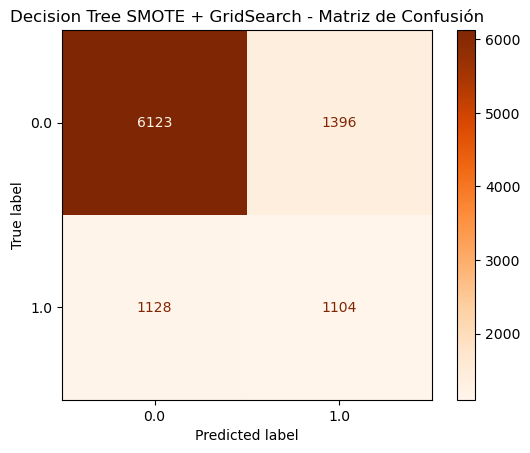

Decision Tree SMOTE + GridSearch - Classification Report:

              precision    recall  f1-score   support

         0.0     0.8444    0.8143    0.8291      7519
         1.0     0.4416    0.4946    0.4666      2232

    accuracy                         0.7412      9751
   macro avg     0.6430    0.6545    0.6479      9751
weighted avg     0.7522    0.7412    0.7461      9751



In [ ]:
# Matriz de confusión
cm_tree_grid_smote = confusion_matrix(y_test, y_pred_tree_grid_smote)
disp_tree_grid_smote = ConfusionMatrixDisplay(cm_tree_grid_smote, display_labels=tree_best_smote.classes_)
disp_tree_grid_smote.plot(cmap=plt.cm.Oranges)
plt.title("Decision Tree SMOTE + GridSearch - Matriz de Confusión")
plt.show()

# Classification Report
print("Decision Tree SMOTE + GridSearch - Classification Report:\n")
print(classification_report(y_test, y_pred_tree_grid_smote, digits=4))

In [ ]:
# Métricas
metricas_ARBOL_DECISION_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_tree_grid_smote)],
    "Precision": [precision_score(y_test, y_pred_tree_grid_smote)],
    "Recall": [recall_score(y_test, y_pred_tree_grid_smote)],
    "F1-score": [f1_score(y_test, y_pred_tree_grid_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_tree_grid_smote)]
}, index=["Decision Tree GridSearch + SMOTE"])

print(metricas_ARBOL_DECISION_GRID_SMOTE)

                                  Accuracy  Precision    Recall  F1-score  \
Decision Tree GridSearch + SMOTE  0.741155     0.4416  0.494624   0.46661   

                                   ROC-AUC  
Decision Tree GridSearch + SMOTE  0.654471  


### Comparar metricas de modelos ARBOL DECISION

In [ ]:
metricas_modelos_arbol = pd.concat([
    metricas_ARBOL_DECISION_GRID,
    metricas_ARBOL_DECISION_SMOTE,
    metricas_ARBOL_DECISION_GRID_SMOTE
])

print(metricas_modelos_arbol)

                                  Accuracy  Precision    Recall  F1-score  \
Decision Tree                     0.774997   0.509397  0.461470   0.48425   
Decision Tree SMOTE               0.741155   0.441600  0.494624   0.46661   
Decision Tree GridSearch + SMOTE  0.741155   0.441600  0.494624   0.46661   

                                   ROC-AUC  
Decision Tree                     0.722362  
Decision Tree SMOTE               0.654471  
Decision Tree GridSearch + SMOTE  0.654471  


# ==================================

# MODELOS RANDOM FOREST

### 5º Modelo: Random Forest

In [ ]:
# Entrenamiento:
from sklearn.ensemble import RandomForestClassifier

# Instanciar Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,        # número de árboles
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=-1                # usar todos los cores disponibles
)

# Entrenar modelo
rf_clf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
# Predicciones:
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

In [ ]:
# Numero de errores:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test != y_pred_rf).sum(), y_test.shape[0])
)

Número de puntos mal clasificados: 1848 de 9751


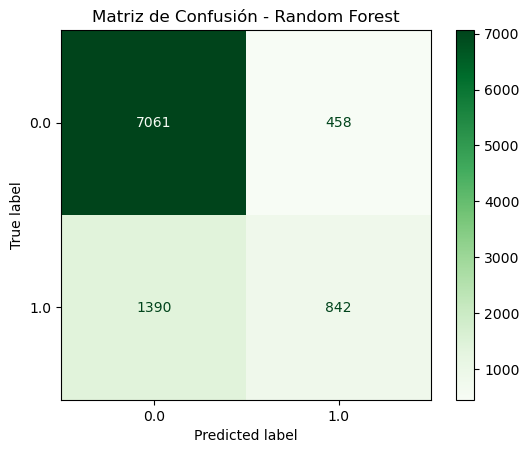

In [ ]:
# Matriz de confusion:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_clf.classes_)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_clf.classes_
)

disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Random Forest")
plt.show()


In [ ]:
# Clasification Report:
print("Classification Report - Random Forest\n")
print(classification_report(y_test, y_pred_rf, digits=4))

Classification Report - Random Forest

              precision    recall  f1-score   support

         0.0     0.8355    0.9391    0.8843      7519
         1.0     0.6477    0.3772    0.4768      2232

    accuracy                         0.8105      9751
   macro avg     0.7416    0.6582    0.6805      9751
weighted avg     0.7925    0.8105    0.7910      9751



In [ ]:
# Tabla metricas:
metricas_RANDOM_FOREST = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "F1-score": [f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf)]
}, index=["Random Forest"])

metricas_RANDOM_FOREST

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.810481,0.647692,0.37724,0.476784,0.800546


### 5.2º Modelo: RANDOM FOREST Gridsearch

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Entrenar GridSearch
grid_rf.fit(X_train, y_train)

# Mejor modelo
rf_best = grid_rf.best_estimator_
print(f"Mejores parámetros (Random Forest + GridSearch): {grid_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (Random Forest + GridSearch): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


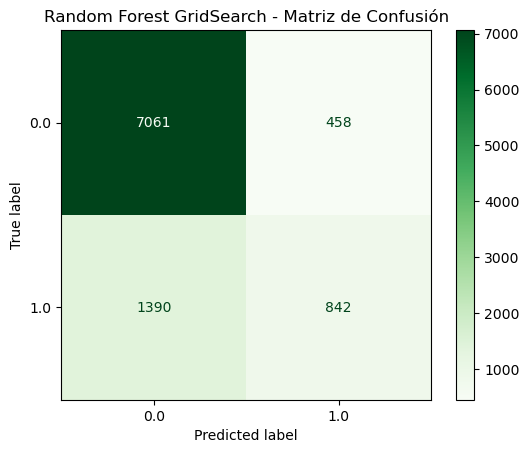

In [ ]:
# Predicciones
y_pred_rf_grid = rf_best.predict(X_test)
y_proba_rf_grid = rf_best.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_rf_grid = confusion_matrix(y_test, y_pred_rf_grid)
disp_rf_grid = ConfusionMatrixDisplay(cm_rf_grid, display_labels=rf_best.classes_)
disp_rf_grid.plot(cmap=plt.cm.Greens)
plt.title("Random Forest GridSearch - Matriz de Confusión")
plt.show()

In [ ]:
# Classification Report
print("Random Forest GridSearch - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_grid, digits=4))

Random Forest GridSearch - Classification Report:

              precision    recall  f1-score   support

         0.0     0.8355    0.9391    0.8843      7519
         1.0     0.6477    0.3772    0.4768      2232

    accuracy                         0.8105      9751
   macro avg     0.7416    0.6582    0.6805      9751
weighted avg     0.7925    0.8105    0.7910      9751



In [ ]:
# Métricas
metricas_RF_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_rf_grid)],
    "Precision": [precision_score(y_test, y_pred_rf_grid)],
    "Recall": [recall_score(y_test, y_pred_rf_grid)],
    "F1-score": [f1_score(y_test, y_pred_rf_grid)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf_grid)]
}, index=["Random Forest GridSearch"])

print(metricas_RF_GRID)

                          Accuracy  Precision   Recall  F1-score   ROC-AUC
Random Forest GridSearch  0.810481   0.647692  0.37724  0.476784  0.800546


### 5.3º Modelo RANDOM FOREST SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # Aplicar SMOTE

rf_smote = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_res, y_train_res)

RandomForestClassifier(n_jobs=-1, random_state=42)

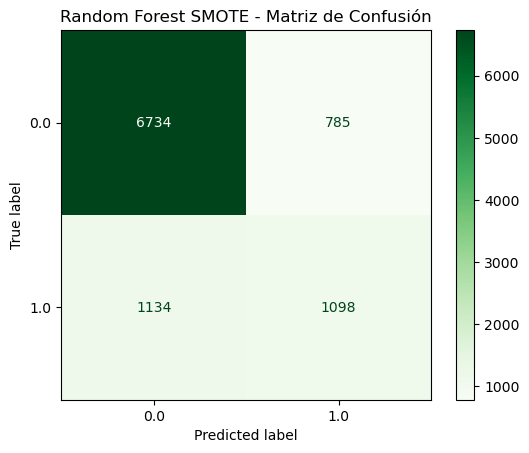

In [ ]:
# Predicciones
y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
disp_rf_smote = ConfusionMatrixDisplay(cm_rf_smote, display_labels=rf_smote.classes_)
disp_rf_smote.plot(cmap=plt.cm.Greens)
plt.title("Random Forest SMOTE - Matriz de Confusión")
plt.show()

In [ ]:
# Classification Report
print("Random Forest SMOTE - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_smote, digits=4))

Random Forest SMOTE - Classification Report:

              precision    recall  f1-score   support

         0.0     0.8559    0.8956    0.8753      7519
         1.0     0.5831    0.4919    0.5337      2232

    accuracy                         0.8032      9751
   macro avg     0.7195    0.6938    0.7045      9751
weighted avg     0.7934    0.8032    0.7971      9751



In [ ]:
# Métricas
metricas_RF_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_rf_smote)],
    "Precision": [precision_score(y_test, y_pred_rf_smote)],
    "Recall": [recall_score(y_test, y_pred_rf_smote)],
    "F1-score": [f1_score(y_test, y_pred_rf_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf_smote)]
}, index=["Random Forest SMOTE"])

print(metricas_RF_SMOTE)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Random Forest SMOTE    0.8032   0.583112  0.491935  0.533657  0.799087


### 5.4º Modelo RANDOM FOREST SMOTE + Gridsearch

In [ ]:
grid_rf_smote = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf_smote.fit(X_train_res, y_train_res)  # Entrenar GridSearch con SMOTE

# Mejor modelo
rf_best_smote = grid_rf_smote.best_estimator_
print(f"Mejores parámetros (Random Forest + SMOTE + GridSearch): {grid_rf_smote.best_params_}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (Random Forest + SMOTE + GridSearch): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


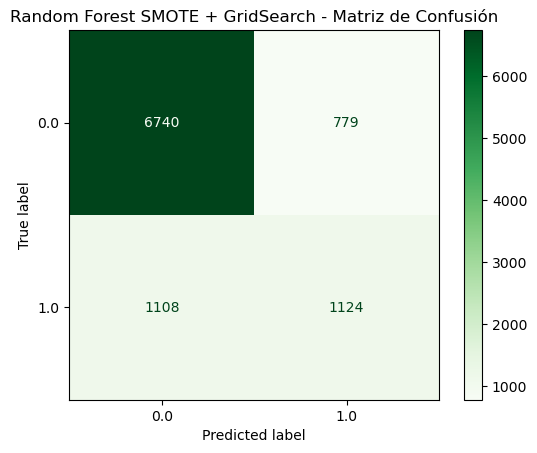

In [ ]:
# Predicciones
y_pred_rf_grid_smote = rf_best_smote.predict(X_test)
y_proba_rf_grid_smote = rf_best_smote.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_rf_grid_smote = confusion_matrix(y_test, y_pred_rf_grid_smote)
disp_rf_grid_smote = ConfusionMatrixDisplay(cm_rf_grid_smote, display_labels=rf_best_smote.classes_)
disp_rf_grid_smote.plot(cmap=plt.cm.Greens)
plt.title("Random Forest SMOTE + GridSearch - Matriz de Confusión")
plt.show()


In [ ]:
# Classification Report
print("Random Forest SMOTE + GridSearch - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_grid_smote, digits=4))


Random Forest SMOTE + GridSearch - Classification Report:

              precision    recall  f1-score   support

         0.0     0.8588    0.8964    0.8772      7519
         1.0     0.5906    0.5036    0.5437      2232

    accuracy                         0.8065      9751
   macro avg     0.7247    0.7000    0.7104      9751
weighted avg     0.7974    0.8065    0.8009      9751



In [ ]:
# Métricas
metricas_RF_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_rf_grid_smote)],
    "Precision": [precision_score(y_test, y_pred_rf_grid_smote)],
    "Recall": [recall_score(y_test, y_pred_rf_grid_smote)],
    "F1-score": [f1_score(y_test, y_pred_rf_grid_smote)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf_grid_smote)]
}, index=["Random Forest SMOTE + GridSearch"])

print(metricas_RF_GRID_SMOTE)

                                  Accuracy  Precision    Recall  F1-score  \
Random Forest SMOTE + GridSearch  0.806481   0.590646  0.503584  0.543652   

                                   ROC-AUC  
Random Forest SMOTE + GridSearch  0.800236  


### Comparar metricas Modelos RANDOM FOREST

In [ ]:
metricas_modelos_rf = pd.concat([
    metricas_RANDOM_FOREST,
    metricas_RF_GRID,
    metricas_RF_SMOTE,
    metricas_RF_GRID_SMOTE
])

print(metricas_modelos_rf)

                                  Accuracy  Precision    Recall  F1-score  \
Random Forest                     0.810481   0.647692  0.377240  0.476784   
Random Forest GridSearch          0.810481   0.647692  0.377240  0.476784   
Random Forest SMOTE               0.803200   0.583112  0.491935  0.533657   
Random Forest SMOTE + GridSearch  0.806481   0.590646  0.503584  0.543652   

                                   ROC-AUC  
Random Forest                     0.800546  
Random Forest GridSearch          0.800546  
Random Forest SMOTE               0.799087  
Random Forest SMOTE + GridSearch  0.800236  


 #### MODELOS CON SMOTE:
 Debido al desbalance de clases en el conjunto de entrenamiento, algunos modelos (como Naive Bayes o Regresión Logística) pueden tender a predecir la clase mayoritaria. <br> Para corregirlo y mejorar métricas como Recall y F1-score, se aplica SMOTE (Synthetic Minority Oversampling Technique), que genera nuevas muestras sintéticas de la clase minoritaria. <br> Nota: SMOTE se aplica solo al conjunto de entrenamiento; los test sets se mantienen intactos.

## TABLA FINAL TODOS LOS MODELOS (COMPARACIÓN)

In [ ]:
# ============================================================
# TABLA FINAL CON TODOS LOS MODELOS Y TODAS LAS MÉTRICAS
# ============================================================

# REGRESIÓN LOGÍSTICA
metricas_modelos_regresion_logistica["Modelo"] = metricas_modelos_regresion_logistica.index
metricas_modelos_regresion_logistica["Algoritmo"] = "Logistic Regression"

# NAIVE BAYES
metricas_modelos_naive_bayes["Modelo"] = metricas_modelos_naive_bayes.index
metricas_modelos_naive_bayes["Algoritmo"] = "Naive Bayes"

# SVM (NO CARGADO → COMENTADO)
metricas_modelos_svm["Modelo"] = metricas_modelos_svm.index
metricas_modelos_svm["Algoritmo"] = "Support Vector Machine"

# ÁRBOL DE DECISIÓN
metricas_modelos_arbol["Modelo"] = metricas_modelos_arbol.index
metricas_modelos_arbol["Algoritmo"] = "Decision Tree"

# RANDOM FOREST
metricas_modelos_rf["Modelo"] = metricas_modelos_rf.index
metricas_modelos_rf["Algoritmo"] = "Random Forest"



# UNIÓN FINAL DE TODOS LOS MODELOS
tabla_metricas_final = pd.concat([
    metricas_modelos_regresion_logistica,
    metricas_modelos_naive_bayes,
    metricas_modelos_svm,   # SVM NO CARGADO
    metricas_modelos_arbol,
    metricas_modelos_rf])

# Reordenar columnas
tabla_metricas_final = tabla_metricas_final[
    ["Algoritmo", "Modelo", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]

# Reset index para presentación
tabla_metricas_final = tabla_metricas_final.reset_index(drop=True)


# NORMALIZAR LA COLUMNA "Modelo"
def etiquetar_modelo(nombre):
    nombre = nombre.lower()
    if "smote" in nombre and "grid" in nombre:
        return "SMOTE + GridSearch"
    elif "smote" in nombre:
        return "SMOTE"
    elif "grid" in nombre:
        return "GridSearch"
    else:
        return "Baseline"

tabla_metricas_final["Modelo"] = tabla_metricas_final["Modelo"].apply(etiquetar_modelo)


# Ordenar:
tabla_metricas_final["ROC_AUC_round"] = tabla_metricas_final["ROC-AUC"].round(3)

tabla_metricas_final = tabla_metricas_final.sort_values(
    by=["ROC_AUC_round", "F1-score", "Recall"],
    ascending=[False, False, False]
).drop(columns="ROC_AUC_round").reset_index(drop=True)

# Mostrar tabla final
print("TABLA FINAL TODOS LOS MODELOS Y MÉTRICAS\n")
print(tabla_metricas_final)


TABLA FINAL TODOS LOS MODELOS Y MÉTRICAS

              Algoritmo              Modelo  Accuracy  Precision    Recall  \
0         Random Forest            Baseline  0.810481   0.647692  0.377240   
1         Random Forest          GridSearch  0.810481   0.647692  0.377240   
2         Random Forest  SMOTE + GridSearch  0.806481   0.590646  0.503584   
3         Random Forest               SMOTE  0.803200   0.583112  0.491935   
4   Logistic Regression            Baseline  0.794401   0.660085  0.209677   
5   Logistic Regression          GridSearch  0.792637   0.633588  0.223118   
6         Decision Tree            Baseline  0.774997   0.509397  0.461470   
7   Logistic Regression  SMOTE + GridSearch  0.712850   0.405960  0.549283   
8   Logistic Regression               SMOTE  0.709568   0.401639  0.548835   
9           Naive Bayes            Baseline  0.707107   0.348837  0.322581   
10          Naive Bayes          GridSearch  0.707107   0.348837  0.322581   
11        Decision Tre

Conclusion: <br>
Aunque el modelo Random Forest sin balanceo presenta un valor de ROC-AUC ligeramente superior, la diferencia respecto al modelo Random Forest con SMOTE y GridSearch es marginal. En cambio, este último muestra una mejora sustancial en el F1-score y, especialmente, en el recall, lo que indica una mayor capacidad para detectar correctamente la clase minoritaria. Por este motivo, el modelo Random Forest con SMOTE y GridSearch se selecciona como el modelo final.

### Entrenar modelo de Regresion Logistica:

In [ ]:
# Definir modelo base para Gridsearch:
log_reg = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    solver="saga")

In [ ]:
# Definir el grid de parametros:
param_grid = {
    "penalty": ["l1", "l2", "elasticnet"],
    "C": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]}

In [ ]:
grid_logreg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1",     
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logreg.fit(X_train, y_train)
print("Mejores parámetros:", grid_logreg.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'C': 0.01, 'l1_ratio': 0.2, 'penalty': 'l1'}


In [ ]:
# Entrenar el mejor modelo
modelo_regresion_logistica = grid_logreg.best_estimator_
modelo_regresion_logistica.fit(X_train, y_train)

LogisticRegression(C=0.01, class_weight='balanced', l1_ratio=0.2,
                   max_iter=10000, penalty='l1', solver='saga')

In [ ]:
# Prediccion:
y_prob = modelo_regresion_logistica.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.55).astype(int)

In [ ]:
# Metricas
nombre_modelo = "Regresion Logistica"

# Calcular métricas globales
fila_resultados = {
    "Modelo": nombre_modelo,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)  # y_proba = predict_proba[:,1]
}

# Crear tabla
tabla_simple = pd.DataFrame([fila_resultados]).round(4)

display(tabla_simple)


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresion Logistica,0.7014,0.4051,0.6505,0.4993,0.7579


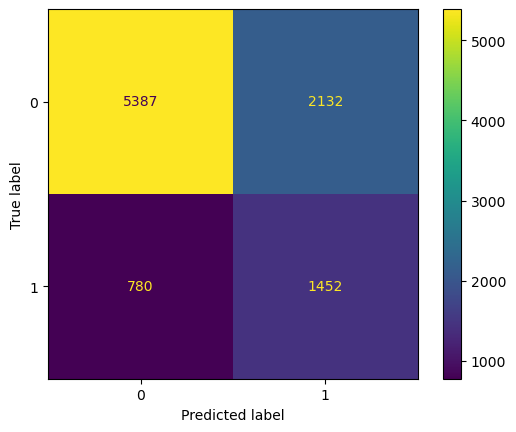

In [ ]:
# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()


# Interpretación de Coeficientes y Odds Ratios en Regresión Logística (Reservas de Hotel)

## Coeficientes 
- Representan el **impacto lineal** de cada variable en el **logaritmo de las probabilidades** de que una reserva sea cancelada.
- **Positivo** → Aumenta la probabilidad de que la reserva se cancele.
- **Negativo** → Disminuye la probabilidad de cancelación (más probabilidad de checkout).
- Se mide en unidades de log-odds, no directamente en probabilidad.

## Odds Ratios (OR)
- Calculados como `OR = exp(coeficiente)`.
- Transforman el coeficiente de la regresión logística en **probabilidad relativa**, lo que facilita la interpretación.
- **OR > 1** → La variable aumenta la probabilidad de que la reserva sea cancelada.
- **OR < 1** → La variable disminuye la probabilidad de cancelación (más chance de checkout).
- Ejemplos de tu caso:
  - `length_of_stay` OR = 849 → A mayor duración de la estancia, la probabilidad de cancelación aumenta muchísimo.
  - `lead_time` OR = 230 → Reservas hechas con mucha antelación tienen mayor probabilidad de cancelación.
  - `City_Donosti` OR = 0.97 → Estar en esta ciudad reduce ligeramente la probabilidad de cancelación.
  - `checkin_day_Monday` OR = 1.0029 → Casi no tiene efecto sobre la cancelación.
  

## En conclusion: 

| Métrica       | Qué muestra                        | Interpretación |
|---------------|-----------------------------------|----------------|
| Coeficiente   | Impacto lineal en logit           | (+) aumenta probabilidad de cancelación, (-) disminuye |
| Odds Ratio    | Probabilidad relativa              | OR >1 aumenta cancelación, OR <1 disminuye cancelación |


Los coeficientes muestran **dirección y magnitud en logit**, mientras que los Odds Ratios muestran **efecto relativo en probabilidad**, más fácil de explicar a alguien que no entienda log-odds.


In [ ]:
# Calcular coeficientes y odds ratios:
coeficientes = modelo_regresion_logistica.coef_[0]
variables = X_train.columns

odds_ratios = np.exp(coeficientes)

# Crear tabla combinada
tabla_coef_odd = pd.DataFrame({
    "Variables": variables,
    "Coeficiente": coeficientes,
    "Odds Ratio": odds_ratios
})

# Ordenar por magnitud del coeficiente
tabla_coef_odd = tabla_coef_odd.reindex(tabla_coef_odd["Coeficiente"].abs().sort_values(ascending=False).index)

print(tabla_coef_odd.round(4))


                                Variables  Coeficiente  Odds Ratio
60               rate_type_Non Refundable      -1.2884      0.2757
62                   libere_community_yes      -0.7403      0.4770
61               returning_inhabitant_yes      -0.5443      0.5803
5                   reservation_net_value       0.4969      1.6436
51   business_segment_Business Individual       0.4166      1.5168
..                                    ...          ...         ...
111                        ciudad_Vitoria       0.0000      1.0000
112                     codigo_ccaa_ES-MD       0.0000      1.0000
113                     codigo_ccaa_ES-NC       0.0000      1.0000
114                     codigo_ccaa_ES-PV       0.0000      1.0000
115                     codigo_ccaa_ES-VC       0.0000      1.0000

[116 rows x 3 columns]


### Analisis de coeficientes y oddsratios

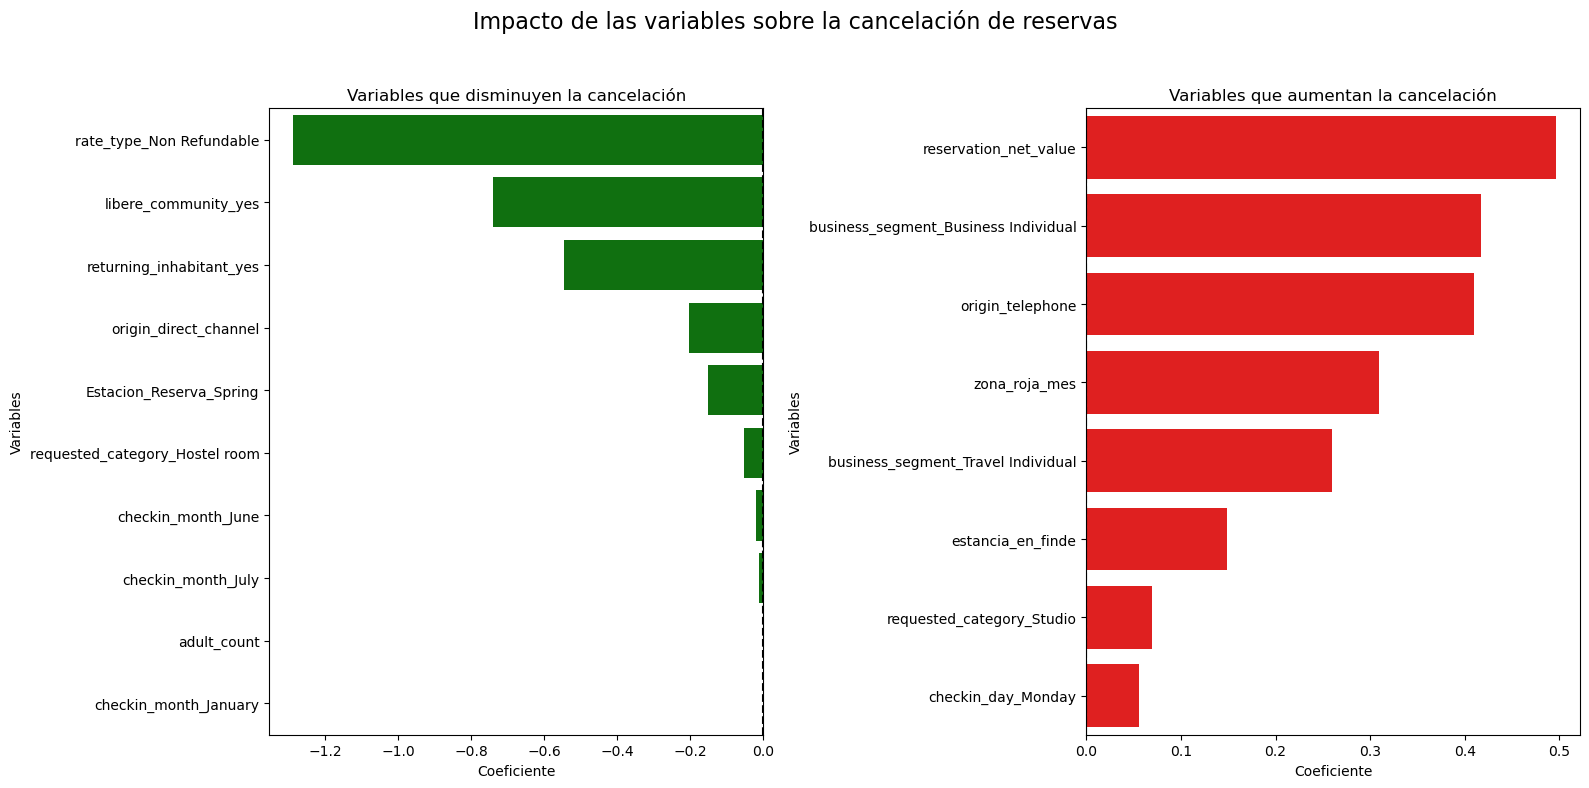

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Crear una nueva columna 'Signo':
# Indica si la variable aumenta o disminuye la cancelación
# Positivo → aumenta la probabilidad de cancelación
# Negativo → disminuye la probabilidad de cancelación
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# 2️⃣ Separar top 10 de cada tipo según valor absoluto del coeficiente
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo'] == 'Aumenta cancelación'].nlargest(10, 'Coeficiente')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo'] == 'Disminuye cancelación'].nsmallest(10, 'Coeficiente')

# 3️⃣ Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 4️⃣ Gráfico izquierdo: top 10 que disminuyen cancelación (verde)
sns.barplot(
    x='Coeficiente',
    y='Variables',
    data=top_disminuye,
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación")
axes[0].axvline(0, color='black', linestyle='--')

# 5️⃣ Gráfico derecho: top 10 que aumentan cancelación (rojo)
sns.barplot(
    x='Coeficiente',
    y='Variables',
    data=top_aumenta,
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación")
axes[1].axvline(0, color='black', linestyle='--')

# 6️⃣ Ajustes finales
plt.suptitle("Impacto de las variables sobre la cancelación de reservas", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


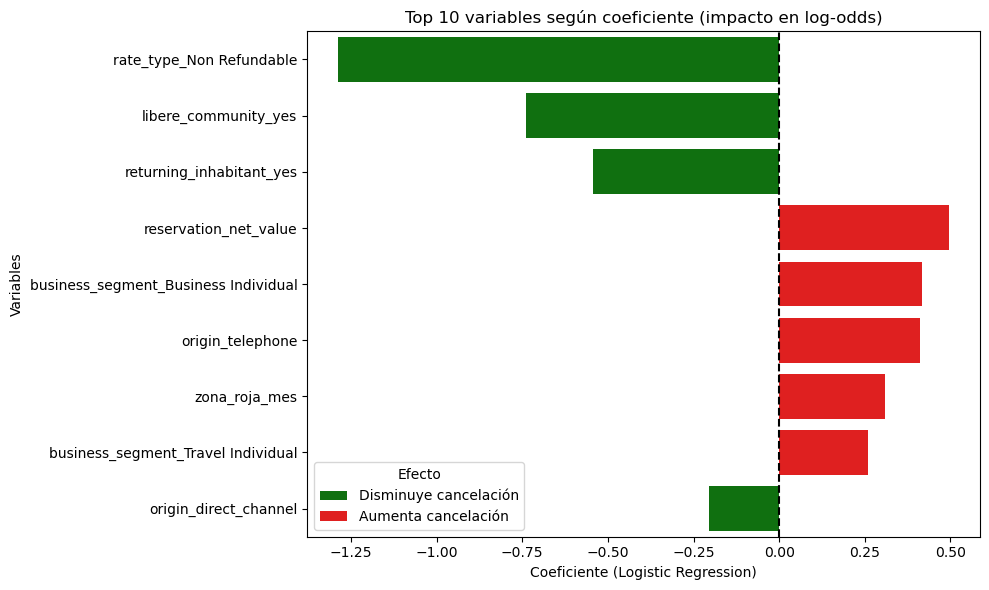

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# Top 10 por magnitud de coeficiente
tabla_top10_coef = tabla_coef_odd.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Coeficiente', 
    y='Variables', 
    data=tabla_top10_coef, 
    hue='Signo', 
    dodge=False,
    palette={'Aumenta cancelación':'red', 'Disminuye cancelación':'green'}
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Top 10 variables según coeficiente (impacto en log-odds)")
plt.xlabel("Coeficiente (Logistic Regression)")
plt.ylabel("Variables")
plt.legend(title='Efecto')
plt.tight_layout()
plt.show()


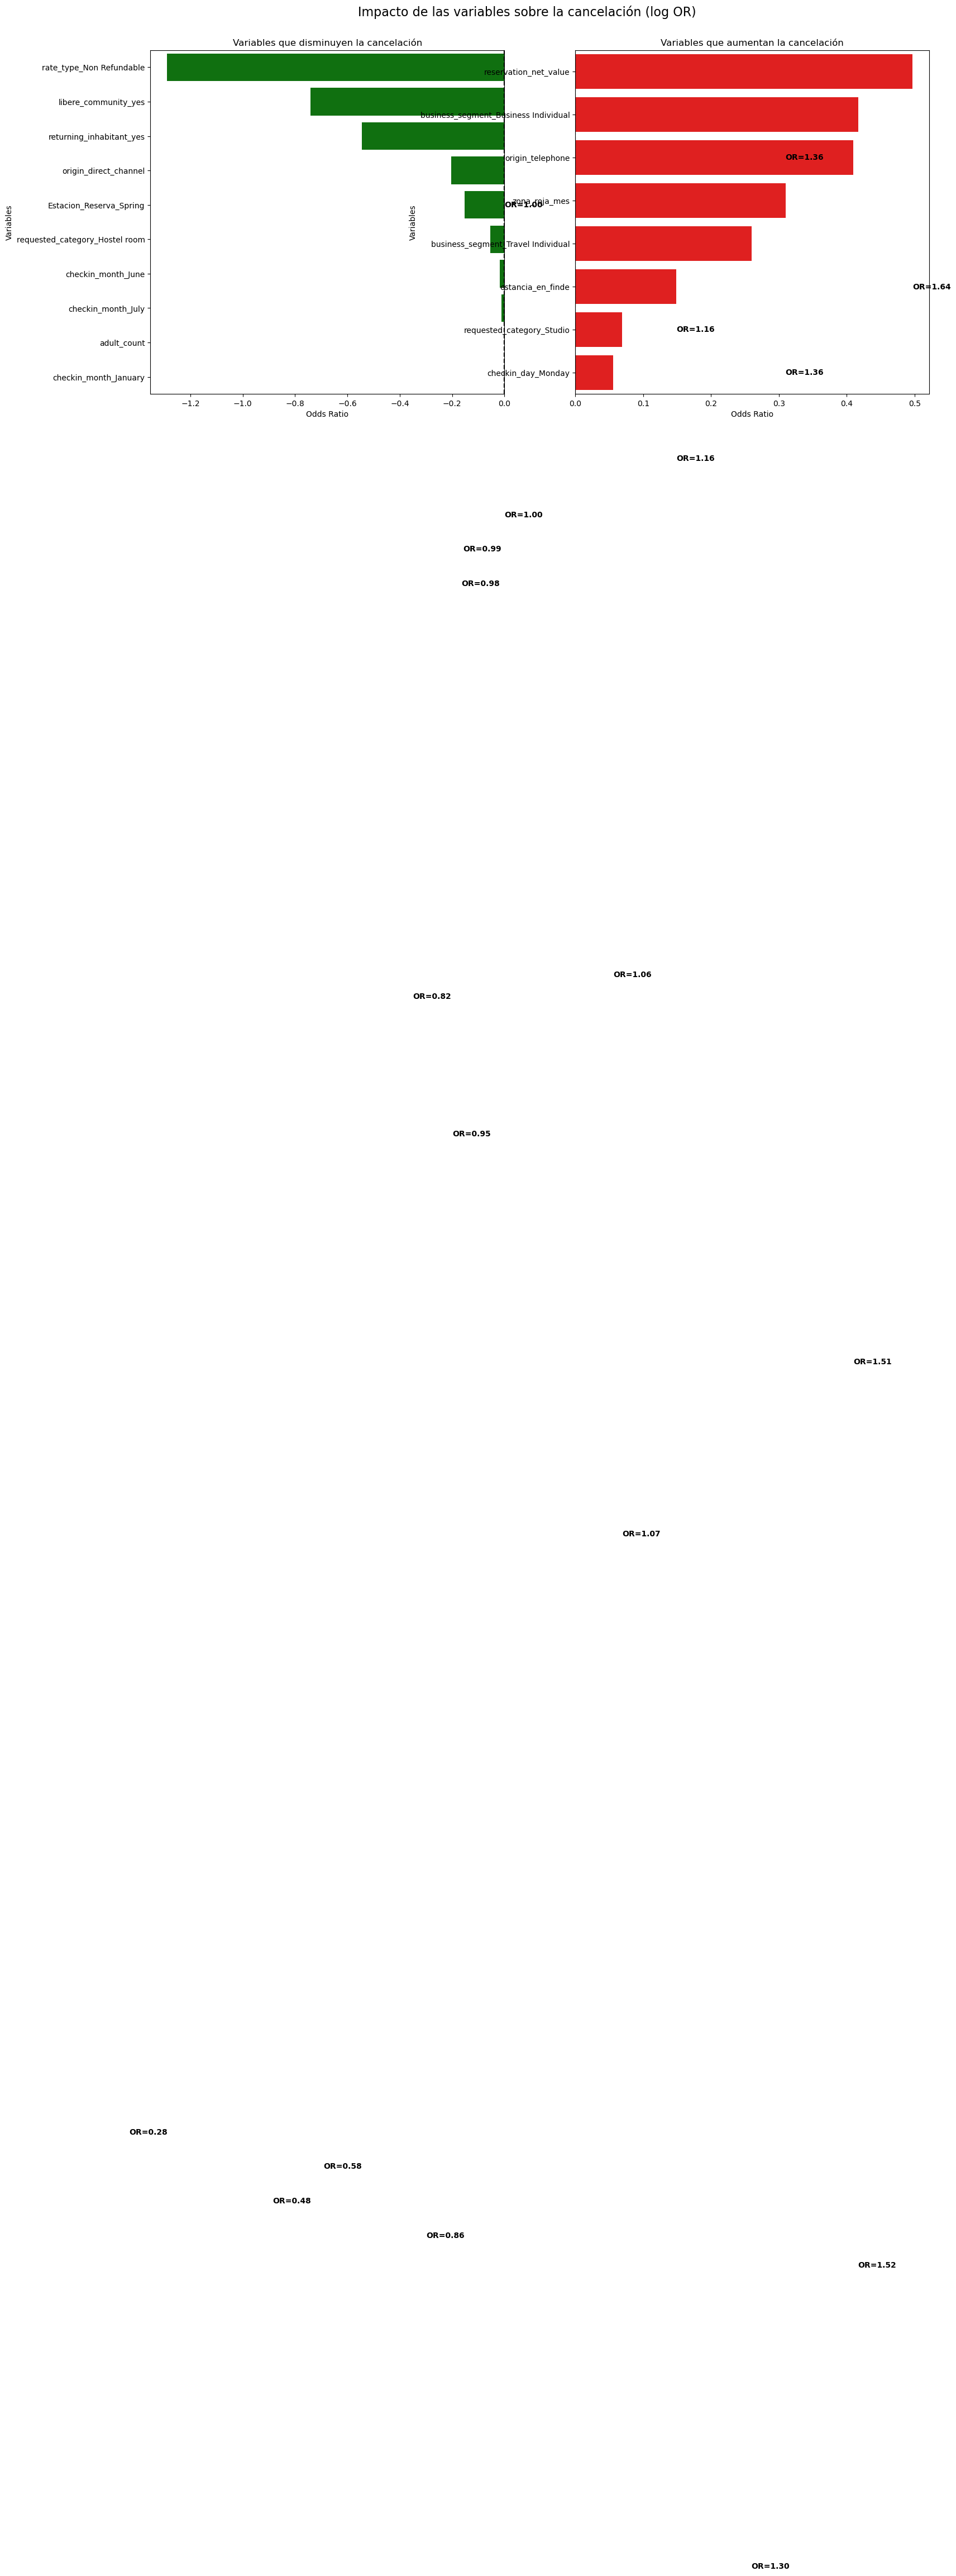

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Crear columna 'Signo'
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# 2️⃣ Top 10 de cada tipo
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo']=='Aumenta cancelación'].nlargest(10,'Coeficiente')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo']=='Disminuye cancelación'].nsmallest(10,'Coeficiente')

# 3️⃣ Crear figura
fig, axes = plt.subplots(1,2, figsize=(18,8))

# 4️⃣ Disminuyen cancelación (OR<1)
sns.barplot(
    x=np.log(top_disminuye['Odds Ratio']),
    y=top_disminuye['Variables'],
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación")
axes[0].axvline(0, color='black', linestyle='--')
for i, row in top_disminuye.iterrows():
    axes[0].text(
        np.log(row['Odds Ratio']),
        i,
        f"OR={row['Odds Ratio']:.2f}",
        va='center',
        ha='right' if row['Coeficiente']<0 else 'left',
        fontweight='bold'
    )

# 5️⃣ Aumentan cancelación (OR>1)
sns.barplot(
    x=np.log(top_aumenta['Odds Ratio']),
    y=top_aumenta['Variables'],
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación")
axes[1].axvline(0, color='black', linestyle='--')
for i, row in top_aumenta.iterrows():
    axes[1].text(
        np.log(row['Odds Ratio']),
        i,
        f"OR={row['Odds Ratio']:.2f}",
        va='center',
        ha='right' if row['Coeficiente']<0 else 'left',
        fontweight='bold'
    )

# 6️⃣ Ajustes finales
plt.suptitle("Impacto de las variables sobre la cancelación (log OR)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


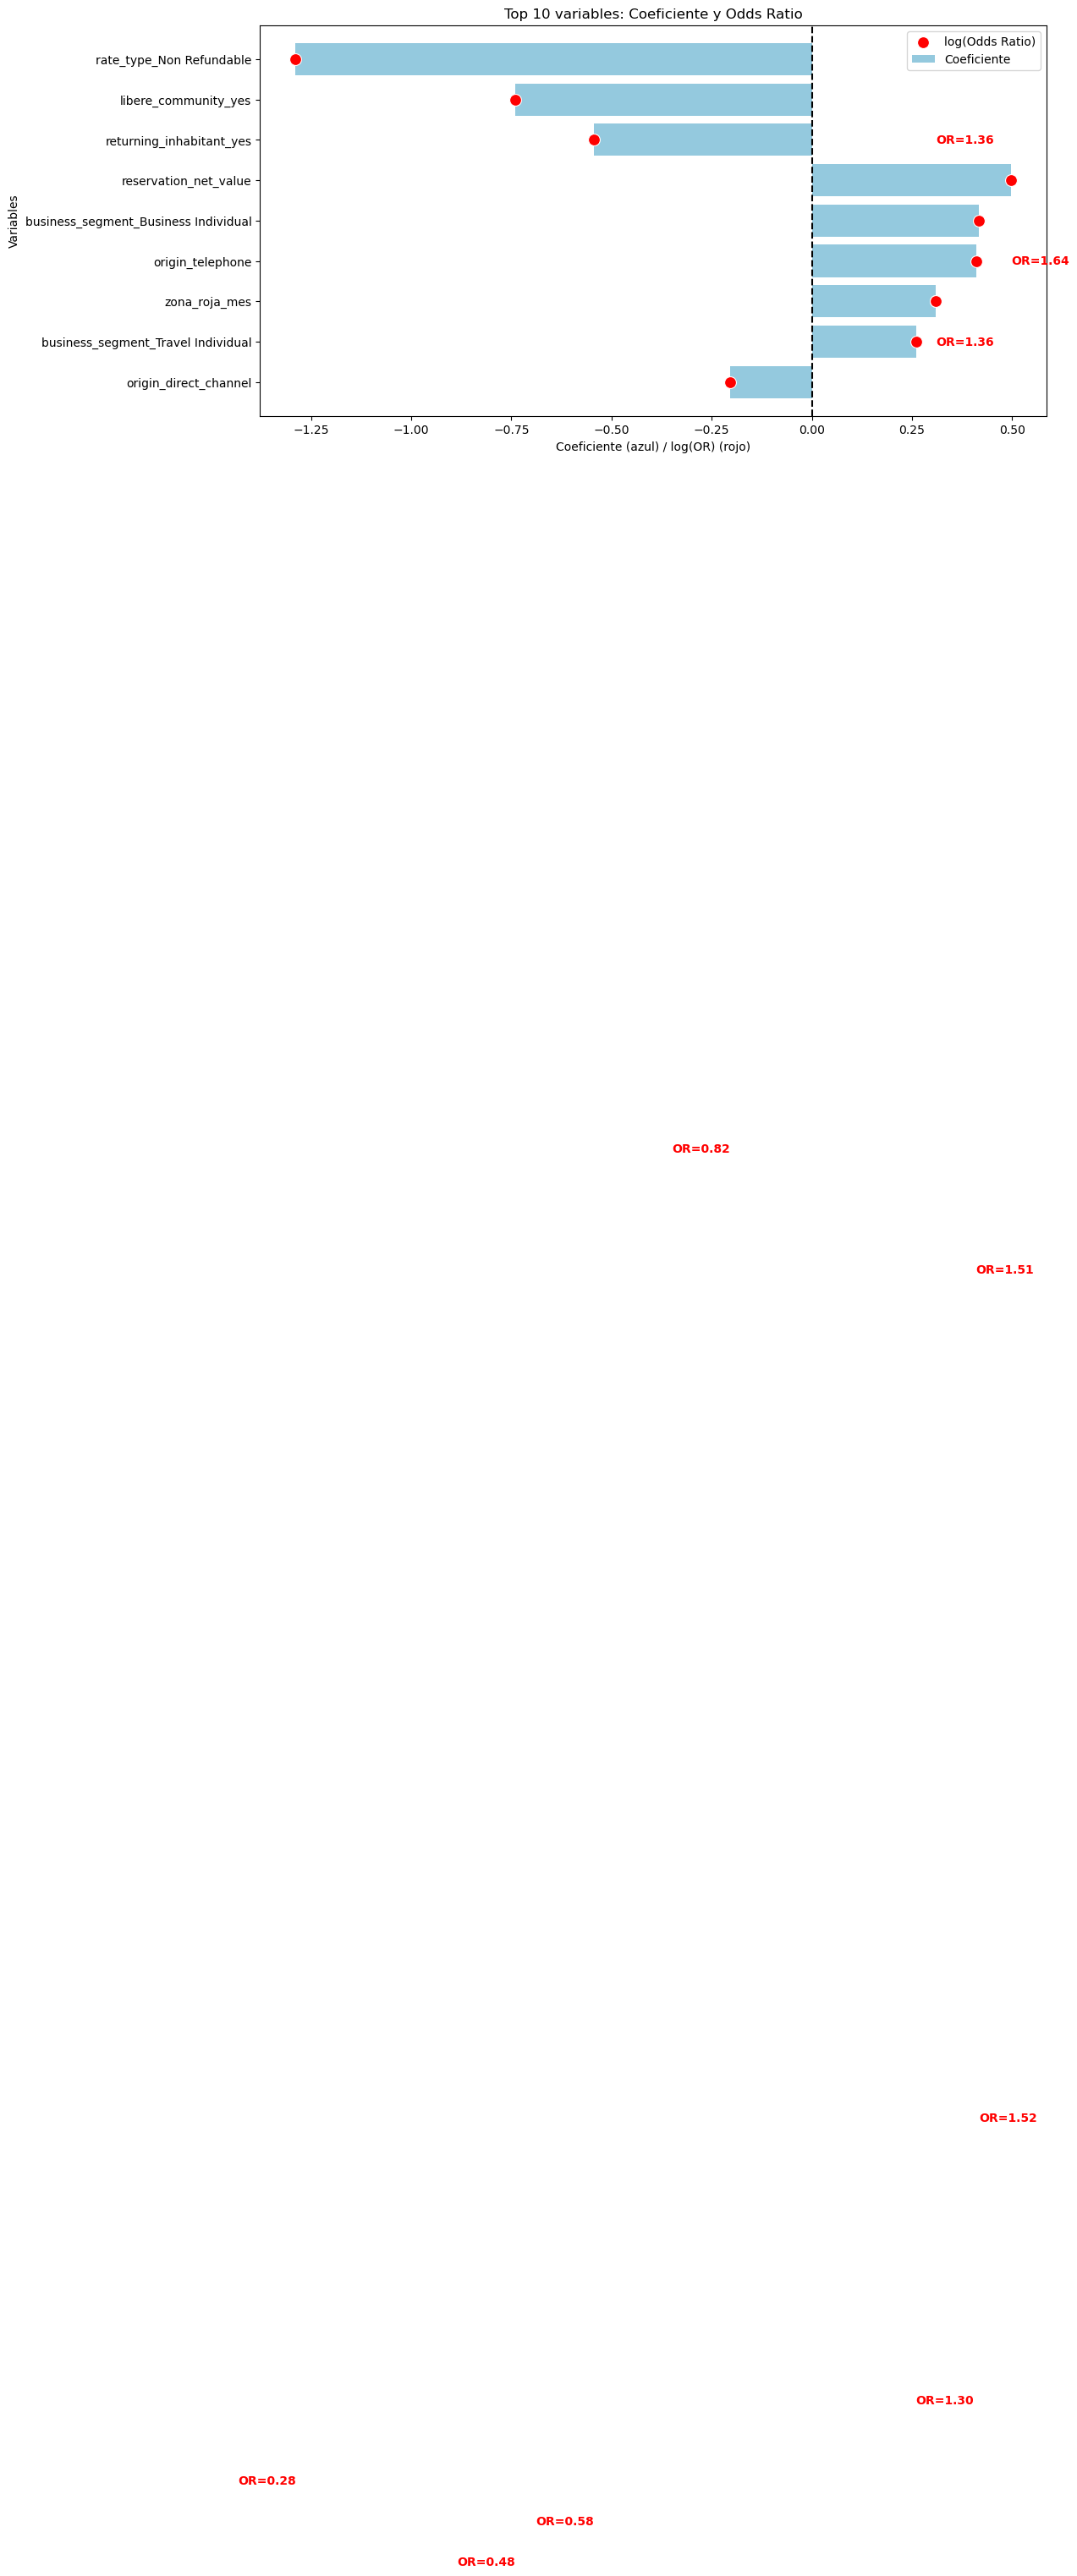

In [ ]:
# Top 10 por magnitud de coeficiente
tabla_top10_comb = tabla_coef_odd.head(10).copy()

# Creamos una columna log(OR) para que se pueda graficar en la misma escala que el coeficiente
tabla_top10_comb['log(OR)'] = np.log(tabla_top10_comb['Odds Ratio'])
plt.figure(figsize=(12,6))

# Barra de coeficiente
sns.barplot(
    x='Coeficiente', 
    y='Variables', 
    data=tabla_top10_comb, 
    color='skyblue', 
    label='Coeficiente'
)

# Línea con los Odds Ratios (convertidos a log para la misma escala)
sns.scatterplot(
    x='log(OR)', 
    y='Variables', 
    data=tabla_top10_comb, 
    color='red', 
    s=100, 
    label='log(Odds Ratio)'
)

# Línea vertical en 0 para separar efecto positivo y negativo
plt.axvline(0, color='black', linestyle='--')

# Añadir texto con el valor de OR
for i, row in tabla_top10_comb.iterrows():
    plt.text(
        row['log(OR)'], 
        i, 
        f"OR={row['Odds Ratio']:.2f}", 
        color='red', 
        fontweight='bold',
        va='center',
        ha='left' if row['log(OR)']>0 else 'right'
    )

plt.title("Top 10 variables: Coeficiente y Odds Ratio")
plt.xlabel("Coeficiente (azul) / log(OR) (rojo)")
plt.ylabel("Variables")
plt.legend()
plt.tight_layout()
plt.show()


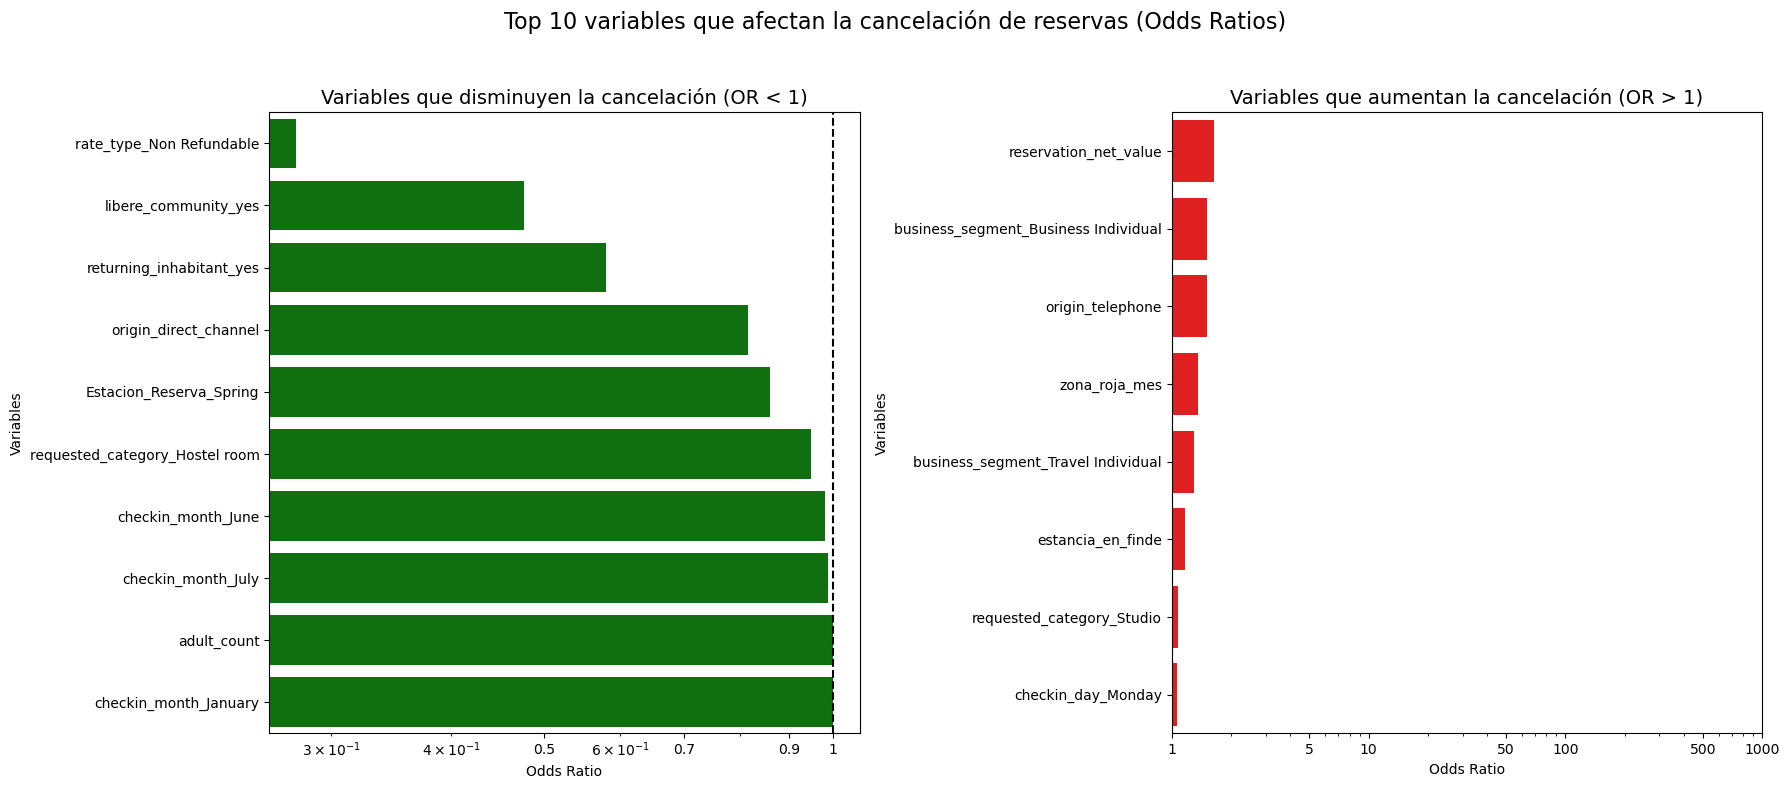

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Crear columna 'Signo' según Odds Ratio
tabla_coef_odd['Signo OR'] = tabla_coef_odd['Odds Ratio'].apply(
    lambda x: 'Aumenta cancelación' if x > 1 else 'Disminuye cancelación'
)

# 2️⃣ Seleccionar top 10 de cada tipo
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo OR'] == 'Aumenta cancelación'].nlargest(10, 'Odds Ratio')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo OR'] == 'Disminuye cancelación'].nsmallest(10, 'Odds Ratio')

# 3️⃣ Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 4️⃣ Gráfico izquierdo: top 10 que disminuyen cancelación (verde)
sns.barplot(
    x='Odds Ratio',
    y='Variables',
    data=top_disminuye,
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación (OR < 1)", fontsize=14)
axes[0].set_xscale('log')
axes[0].set_xticks([0.5, 0.7, 0.9, 1])
axes[0].set_xticklabels([0.5, 0.7, 0.9, 1])
axes[0].axvline(1, color='black', linestyle='--')  # referencia OR=1

# 5️⃣ Gráfico derecho: top 10 que aumentan cancelación (rojo)
sns.barplot(
    x='Odds Ratio',
    y='Variables',
    data=top_aumenta,
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación (OR > 1)", fontsize=14)
axes[1].set_xscale('log')
axes[1].set_xticks([1, 5, 10, 50, 100, 500, 1000])
axes[1].set_xticklabels([1, 5, 10, 50, 100, 500, 1000])
axes[1].axvline(1, color='black', linestyle='--')  # referencia OR=1

# 6️⃣ Ajustes finales
plt.suptitle("Top 10 variables que afectan la cancelación de reservas (Odds Ratios)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
